In [1]:
# Load dependencies
import pandas as pd
from matplotlib import pyplot as plt
from pprint import pprint
from scipy import stats
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import fdrcorrection
from met_brewer.palettes import (
    MET_PALETTES, COLORBLIND_PALETTES_NAMES, COLORBLIND_PALETTES,
    met_brew, export, is_colorblind_friendly
)
from IPython.display import display

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import fdrcorrection
import os

def plot_permutation_histogram(permuted_means, observed_mean, p_value, analysis_col, 
                              roi=None, cond=None, ax=None, test_type="two_tailed"):
    """
    Plot histogram of permuted means with observed mean marked.
    
    Parameters:
    -----------
    permuted_means : array-like
        Array of permuted means from null distribution
    observed_mean : float
        The observed mean value
    p_value : float
        P-value from permutation test
    analysis_col : str
        Name of the analysis column for labeling
    roi : str or None
        ROI name for title
    cond : str or None
        Condition name for title
    ax : matplotlib axis or None
        Axis to plot on. If None, creates new figure
    test_type : str
        Type of test performed
    
    Returns:
    --------
    ax : matplotlib axis
        The axis object with the plot
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    
    # Plot histogram of permuted means
    ax.hist(permuted_means, bins=50, alpha=0.7, color='skyblue', 
           density=True, label='Permuted means')
    
    # Mark observed mean
    ax.axvline(observed_mean, color='red', linestyle='--', linewidth=2, 
              label=f'Observed mean = {observed_mean:.3f}')
    
    # Add p-value text
    ax.text(0.05, 0.95, f'p = {p_value:.4f}', 
           transform=ax.transAxes, verticalalignment='top',
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Set labels and title
    title_parts = []
    if roi is not None:
        title_parts.append(f'ROI: {roi}')
    if cond is not None:
        title_parts.append(f'Cond: {cond}')
    if not title_parts:
        title_parts.append('All data')
    
    ax.set_title(', '.join(title_parts))
    ax.set_xlabel(f'Mean {analysis_col}')
    ax.set_ylabel('Density')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    return ax

def create_permutation_plots(results_list, analysis_col, test_type, save_plots=False, plot_dir="permutation_plots"):
    """
    Create subplot grid of permutation histograms.
    
    Parameters:
    -----------
    results_list : list of dict
        List of dictionaries containing plot data for each test
    analysis_col : str
        Name of analysis column
    test_type : str
        Type of test performed
    save_plots : bool
        Whether to save plots to files
    plot_dir : str
        Directory to save plots
    
    Returns:
    --------
    fig : matplotlib figure
        The figure object with all plots
    """
    n_plots = len(results_list)
    if n_plots == 0:
        return None
    
    # Calculate subplot dimensions
    n_cols = min(3, n_plots)
    n_rows = (n_plots + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    
    # Handle single plot case
    if n_plots == 1:
        axes = [axes]
    elif n_rows == 1:
        axes = axes
    else:
        axes = axes.flatten()
    
    # Create plots
    for i, result in enumerate(results_list):
        plot_permutation_histogram(
            permuted_means=result['permuted_means'],
            observed_mean=result['observed_mean'],
            p_value=result['p_value'],
            analysis_col=analysis_col,
            roi=result['roi'],
            cond=result['cond'],
            ax=axes[i],
            test_type=test_type
        )
    
    # Hide empty subplots
    for i in range(n_plots, len(axes)):
        axes[i].set_visible(False)
    
    plt.tight_layout()
    
    # Save if requested
    if save_plots:
        os.makedirs(plot_dir, exist_ok=True)
        filename = f"{plot_dir}/permutation_histograms_{analysis_col}_{test_type}.png"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"Histograms saved to: {filename}")
    
    plt.show()
    return fig

def run_permutation_test(
    data_df, 
    analysis_col,
    group_cols=["roi", "cond"],
    conditions=None,
    rois=None,
    n_permutations=10000, 
    seed=42,
    alpha=0.05,
    test_type="two_tailed",
    correction_method="across_rois",
    plot_histograms=False,
    save_plots=False,
    plot_dir="permutation_plots"
):
    """
    Run permutation tests for any variable with flexible FDR correction options.
    
    Parameters:
    -----------
    data_df : pandas.DataFrame
        DataFrame with the data to analyze
    analysis_col : str
        Name of the column to analyze with permutation test
    group_cols : list
        List of columns to group by (e.g., ["roi", "cond"])
    conditions : list or None
        List of conditions to analyze. If None, all conditions are analyzed
    rois : list or None
        List of ROIs to analyze. If None, all ROIs are analyzed
    n_permutations : int
        Number of permutations to run
    seed : int
        Random seed for reproducibility
    alpha : float
        Significance level for FDR correction
    test_type : str
        Type of test to perform: "two_tailed", "greater", or "less"
    correction_method : str
        How to apply FDR correction:
        - "across_rois": Correct across ROIs within each condition (default)
        - "across_conditions": Correct across conditions within each ROI
        - "all_tests": Correct across all tests simultaneously
    plot_histograms : bool
        Whether to generate histogram plots
    save_plots : bool
        Whether to save plots to files
    plot_dir : str
        Directory to save plots (created if doesn't exist)
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with permutation test results including FDR-corrected p-values
    """
    # Validate parameters
    valid_test_types = ["two_tailed", "greater", "less"]
    if test_type not in valid_test_types:
        raise ValueError(f"test_type must be one of {valid_test_types}, got '{test_type}'")
    
    valid_correction_methods = ["across_rois", "across_conditions", "all_tests"]
    if correction_method not in valid_correction_methods:
        raise ValueError(f"correction_method must be one of {valid_correction_methods}, got '{correction_method}'")
    
    # Set random seed for reproducibility
    np.random.seed(seed)
    
    # Extract unique values for grouping variables if not provided
    if "roi" in group_cols and "roi" in data_df.columns:
        if rois is None:
            rois = data_df["roi"].unique()
    else:
        rois = [None]
        
    if "cond" in group_cols and "cond" in data_df.columns:
        if conditions is None:
            conditions = data_df["cond"].unique()
    else:
        conditions = [None]
    
    # Prepare results storage
    results = []
    plot_data = []  # Store data for plotting separately
    
    # Loop through ROIs and conditions
    for roi_idx, roi in enumerate(rois):
        if roi is not None:
            print(f"Processing ROI: {roi} ({roi_idx+1}/{len(rois)})")
        for cond in conditions:
            # Filter data
            filtered_data = data_df.copy()
            if roi is not None and "roi" in data_df.columns:
                filtered_data = filtered_data[filtered_data["roi"] == roi]
            if cond is not None and "cond" in data_df.columns:
                filtered_data = filtered_data[filtered_data["cond"] == cond]
            
            cond_data = filtered_data[analysis_col].values
            
            if len(cond_data) == 0:
                continue
                
            # Calculate observed mean
            observed_mean = np.mean(cond_data)
            
            # Perform permutation test against null hypothesis (mean = 0)
            # Generate all permuted means first
            permuted_means = []
            for _ in range(n_permutations):
                # Generate permutation by randomly flipping signs
                signs = np.random.choice([-1, 1], size=len(cond_data))
                permuted_data = cond_data * signs
                permuted_mean = np.mean(permuted_data)
                permuted_means.append(permuted_mean)
            
            permuted_means = np.array(permuted_means)
            
            # Apply appropriate test based on test_type using sum()
            if test_type == 'greater':
                p_value = np.sum(permuted_means >= observed_mean) / n_permutations
            elif test_type == 'less':
                p_value = np.sum(permuted_means <= observed_mean) / n_permutations
            elif test_type == 'two_tailed':
                p_value = np.sum(np.abs(permuted_means) >= np.abs(observed_mean)) / n_permutations
            
            # Store plot data if plotting is requested
            if plot_histograms:
                plot_data.append({
                    'permuted_means': permuted_means,
                    'observed_mean': observed_mean,
                    'p_value': p_value,
                    'roi': roi,
                    'cond': cond
                })
            
            # Store results
            results.append({
                "roi": roi,
                "cond": cond,
                "observed_mean": observed_mean,
                "std_error": np.std(cond_data, ddof=1) / np.sqrt(len(cond_data)),
                "n": len(cond_data),
                "p_value": p_value,
                "test_type": test_type,
                "significant": p_value < alpha
            })
    
    # Create plots if requested
    if plot_histograms and plot_data:
        create_permutation_plots(plot_data, analysis_col, test_type, save_plots, plot_dir)
    
    # Convert to DataFrame
    results_df = pd.DataFrame(results)
    
    if len(results_df) == 0:
        return results_df
    
    # Apply FDR correction based on specified method
    results_df["p_value_fdr"] = np.nan
    results_df["significant_fdr"] = False
    results_df["n_corrections"] = 0
    
    if correction_method == "across_rois" and "cond" in group_cols and "cond" in results_df.columns:
        # Apply FDR correction across ROIs within each condition
        for cond in results_df["cond"].unique():
            cond_mask = results_df["cond"] == cond
            cond_p_values = results_df[cond_mask]["p_value"].values
            
            if len(cond_p_values) > 0:
                rejected, p_corrected = fdrcorrection(cond_p_values, alpha=alpha, method='indep')
                
                results_df.loc[cond_mask, "p_value_fdr"] = p_corrected
                results_df.loc[cond_mask, "significant_fdr"] = rejected
                results_df.loc[cond_mask, "n_corrections"] = len(cond_p_values)
                
    elif correction_method == "across_conditions" and "roi" in group_cols and "roi" in results_df.columns:
        # Apply FDR correction across conditions within each ROI
        for roi in results_df["roi"].unique():
            roi_mask = results_df["roi"] == roi
            roi_p_values = results_df[roi_mask]["p_value"].values
            
            if len(roi_p_values) > 0:
                rejected, p_corrected = fdrcorrection(roi_p_values, alpha=alpha, method='indep')
                
                results_df.loc[roi_mask, "p_value_fdr"] = p_corrected
                results_df.loc[roi_mask, "significant_fdr"] = rejected
                results_df.loc[roi_mask, "n_corrections"] = len(roi_p_values)
                
    elif correction_method == "all_tests":
        # Apply FDR correction to all tests simultaneously
        all_p_values = results_df["p_value"].values
        if len(all_p_values) > 0:
            rejected, p_corrected = fdrcorrection(all_p_values, alpha=alpha, method='indep')
            results_df["p_value_fdr"] = p_corrected
            results_df["significant_fdr"] = rejected
            results_df["n_corrections"] = len(all_p_values)
    else:
        # Fallback to all tests correction if specified method doesn't apply
        all_p_values = results_df["p_value"].values
        if len(all_p_values) > 0:
            rejected, p_corrected = fdrcorrection(all_p_values, alpha=alpha, method='indep')
            results_df["p_value_fdr"] = p_corrected
            results_df["significant_fdr"] = rejected
            results_df["n_corrections"] = len(all_p_values)
    
    # Sort and return
    sort_cols = [col for col in ["roi", "cond"] if col in results_df.columns] + ["p_value"]
    results_df = results_df.sort_values(by=sort_cols)
    
    return results_df


def benjamini_hochberg_correction(p_values, alpha=0.05):
    """Apply Benjamini-Hochberg FDR correction using statsmodels."""
    rejected, p_corrected = fdrcorrection(p_values, alpha=alpha, method='indep')
    return p_corrected, rejected

In [3]:
def calculate_facilitation(df, glm=False):
    """
    Calculate facilitation effects from RSA results DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame with RSA results containing columns: 'sub', 'roi', 'cond', 'corr_diff'
        where corr_diff is already calculated as (diag - off_diag)
    
    Returns:
    --------
    results_df : pandas.DataFrame
        DataFrame with comparison conditions for each subject and ROI
    """
    import pandas as pd
    
    results = []
    
    # Process each subject and ROI
    for sub in df['sub'].unique():
        for roi in df['roi'].unique():
            # Get data for this subject and ROI
            sub_roi_data = df[(df['sub'] == sub) & (df['roi'] == roi)]
            
            # Extract corr_diff values for each condition
            values = {}
            for _, row in sub_roi_data.iterrows():
                if glm==True:
                    values[row['cond']] = row['corr']
                else:
                    values[row['cond']] = row['z_similarity']
            
            # Check if we have the required base conditions
            if not all(cond in values for cond in ['A-A', 'V-V', 'C-C']):
                continue
            
            if glm==True: 
                c_val = values['C-C']
                a_val = values['A-A']
                v_val = values['V-V']
                i_val = values['incongruent']
            else:
                c_val = values['C-C']
                a_val = values['A-A']
                v_val = values['V-V']
                ic_a_val_uni = values['A-IC_A']
                ic_v_val_uni = values['V-IC_V']
                ic_a_val_IC = values['A-IC_A']
                ic_v_val_IC = values['V-IC_V']
                        
            # Get incongruent conditions
            if glm==True:
                mean_pure_av = np.mean([a_val, v_val])
            else:
                mean_inc_uni = np.mean([ic_a_val_uni, ic_v_val_uni])
                mean_inc_IC = np.mean([ic_a_val_IC, ic_v_val_IC])
                mean_pure_av = np.mean([a_val, v_val])
                
                        
            # Define all comparisons
            if glm==True:
                comparisons = [
                    ('C_v_mean_pure_AV', c_val - mean_pure_av),
                    ('C_v_I', c_val - i_val),
                    ('C_v_A', c_val - a_val),
                    ('C_v_V', c_val - v_val),
                ]
                
            else:
                comparisons = [
                    ('C_v_A', c_val - a_val),
                    ('C_v_V', c_val - v_val),
                    ('C_v_mean_pure_AV', c_val - mean_pure_av),
                    ('V_v_A', v_val - a_val),
                    ('C_v_mean_incongruent_uni', c_val - mean_inc_uni),
                    ('C_v_mean_incongruent_IC', c_val - mean_inc_IC),
                    ('mean_pure_AV_v_mean_incongruent', mean_pure_av - mean_inc_uni),
                    ('mean_incongruent_v_mean_pure_AV', mean_inc_uni - mean_pure_av),
                    ('C_v_IC_A', c_val - ic_a_val_uni),
                    ('C_v_IC_V', c_val - ic_v_val_uni),
                    ('A_v_IC_A', a_val - ic_a_val_uni),
                    ('V_v_IC_V', v_val - ic_v_val_uni),
                ]
        
            # Add all comparisons to results
            for comp_cond, comp_val in comparisons:
                results.append({
                    'sub': sub, 
                    'roi': roi, 
                    'cond': comp_cond, 
                    'corr_diff': comp_val
                })
    
    return pd.DataFrame(results)

In [4]:
def plot_roi_correlations(df, x_col='roi', y_col='corr_diff', hue_col='cond', 
                          roi_order=None, condition_order=None, 
                          palette=None, alpha=0.8, ylim=None, yticks=None,
                          custom_legend_labels=None, title=None,
                          fig_height=6,
                          ylabel=r"Scene-specific similarity ($\mathit{z}$)",
                          show_points=True, point_alpha=0.8, point_size=3,
                          point_lightness=0.15, hatch_conditions=None, figure_width=10, 
                          auto_scale_points=True, show_legend=True, x_label_rotation=0,
                          show_zero_line=True, condition_offsets=None):
    """
    Create a scientific publication-style bar plot matching Nature/Science figure aesthetics.
    Now supports condition-specific alpha values and lighter dots.
    
    Parameters:
    -----------
    alpha : float or list/tuple
        If float, applies same alpha to all conditions.
        If list/tuple, applies different alpha to each condition in condition_order.
    point_size : float
        Base size for scatter points. Will auto-scale based on number of conditions
        if auto_scale_points=True. Default 3.
    point_lightness : float
        Factor to lighten the dot edge colors relative to bar colors (0=same color, 1=white).
        Default 0.15 for subtle lightening.
    hatch_conditions : list or None
        List of condition names that should have diagonal hatch pattern (///).
        If None, no hatching is applied. Example: ['A-A', 'V-V']
    auto_scale_points : bool
        If True (default), automatically scales point size based on number of 
        conditions to maintain visual proportions. If False, uses fixed point_size value.
    show_legend : bool
        If True (default), displays the legend. If False, hides the legend.
    x_label_rotation : float
        Rotation angle for x-axis labels in degrees. Default 0 (horizontal).
        Use 45 for diagonal labels when x-axis is crowded.
    show_zero_line : bool
        If True (default), adds a dashed horizontal line at y=0.
    condition_offsets : dict or None
        Dictionary mapping condition names to x-axis offsets. 
        Example: {'C-C': 0.05} shifts the "C-C" condition 0.05 units to the right.
        Useful for visually separating similar conditions while keeping bar groups centered.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Rectangle
    from matplotlib.colors import to_rgba
    from matplotlib.legend_handler import HandlerBase
    import matplotlib.font_manager as fm
    
    def lighten_color(color, factor=0.3):
        """Lighten a color by blending with white"""
        rgba = to_rgba(color)
        return tuple(c + (1 - c) * factor for c in rgba[:3]) + (rgba[3],)
    
    class HatchedRectangleHandler(HandlerBase):
        """Custom legend handler for hatched rectangles with black outline"""
        def __init__(self, hatch_color, alpha=0.8):
            self.hatch_color = hatch_color
            self.alpha = alpha
            super().__init__()
            
        def create_artists(self, legend, orig_handle, xdescent, ydescent,
                         width, height, fontsize, trans):
            # Create white rectangle with colored hatching
            hatched_rect = Rectangle((xdescent, ydescent), width, height,
                                    facecolor='white', alpha=self.alpha,
                                    hatch='///', edgecolor=self.hatch_color,
                                    linewidth=1.2, transform=trans)
            # Create black outline
            outline_rect = Rectangle((xdescent, ydescent), width, height,
                                    facecolor='none', edgecolor='black',
                                    linewidth=0.8, transform=trans)
            return [hatched_rect, outline_rect]
    
    # Set defaults
    roi_order = roi_order or ["HPC", "CA1", "CA2+3", "DG", "EC", "PRC", "Subiculum"]
    condition_order = condition_order or ["A-A", "A-IC_A", "V-V", "V-IC_V", "C-C", 'V-A']
    palette = palette or ['#d63384', '#6f42c1', '#20c997', '#fd7e14', '#6c757d']
    
    n_rois = len(roi_order)
    n_conditions = len(condition_order)
    
    # Clear any existing figures to avoid state issues
    plt.close('all')
    
    # Reset matplotlib to clean state
    plt.rcdefaults()
    
    # Set consistent font sizes with Liberation Sans (Helvetica clone)
    # Liberation Sans is metrically compatible with Helvetica and widely available
    # Use mathtext for proper rendering of italic z
    plt.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Liberation Sans', 'Helvetica', 'Arial', 'DejaVu Sans'],
        'font.size': 14,
        'axes.titlesize': 16,
        'axes.labelsize': 14,
        'xtick.labelsize': 13,
        'ytick.labelsize': 13,
        'legend.fontsize': 12,
        'axes.linewidth': 1.5,
        'xtick.major.width': 1.5,
        'ytick.major.width': 1.5,
        'xtick.minor.width': 1.0,
        'ytick.minor.width': 1.0,
        'mathtext.default': 'regular',  # Use regular font for math, not italic by default
        'mathtext.fontset': 'custom',
        'mathtext.rm': 'Liberation Sans',
        'mathtext.it': 'Liberation Sans:italic',
        'mathtext.bf': 'Liberation Sans:bold',
    })
    
    sns.set_style("white")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(figure_width, fig_height), dpi=150)
    
    # Create barplot with seaborn
    sns.barplot(data=df, x=x_col, y=y_col, hue=hue_col,
                order=roi_order, hue_order=condition_order,
                palette=palette, ax=ax, errorbar='se',
                capsize=.05, errwidth=1.2)
    
    # Store error bar lines before styling them
    error_bar_lines = list(ax.lines)
    
    # Style error bars
    for line in error_bar_lines:
        line.set_color('black')
        line.set_linewidth(1.2)
        line.set_zorder(15)
    
    # Process alpha values
    if isinstance(alpha, (list, tuple)):
        alpha_values = list(alpha) + [0.8] * (n_conditions - len(alpha))
    else:
        alpha_values = [alpha] * n_conditions
    
    # The patches are created in order: all bars for condition 1, then all for condition 2, etc.
    # So we need to reorganize them by ROI and condition
    all_patches = ax.patches
    patches_per_condition = n_rois
    
    # Create a mapping of (roi_idx, cond_idx) to patch
    patch_map = {}
    for cond_idx in range(n_conditions):
        start_idx = cond_idx * patches_per_condition
        end_idx = start_idx + patches_per_condition
        condition_patches = all_patches[start_idx:end_idx]
        for roi_idx, patch in enumerate(condition_patches):
            patch_map[(roi_idx, cond_idx)] = patch
    
    # Apply alpha and hatching to patches, and shift error bars
    # Error bars are created in the same order as patches: 3 lines per bar (vertical + 2 caps)
    lines_per_bar = 3  # vertical line + 2 cap lines
    
    for roi_idx in range(n_rois):
        for cond_idx in range(n_conditions):
            patch = patch_map[(roi_idx, cond_idx)]
            condition = condition_order[cond_idx]
            
            # Calculate which error bar lines correspond to this patch
            bar_index = cond_idx * n_rois + roi_idx
            line_start_idx = bar_index * lines_per_bar
            
            # Apply x-axis offset if specified
            if condition_offsets and condition in condition_offsets:
                offset = condition_offsets[condition]
                patch.set_x(patch.get_x() + offset)
                
                # Shift the corresponding error bar lines
                for line_idx in range(line_start_idx, min(line_start_idx + lines_per_bar, len(error_bar_lines))):
                    line = error_bar_lines[line_idx]
                    xdata = line.get_xdata()
                    line.set_xdata(xdata + offset)
            
            # Apply alpha
            patch.set_alpha(alpha_values[cond_idx])
            
            # Apply hatching if needed
            if hatch_conditions and condition in hatch_conditions:
                patch.set_facecolor('white')
                patch.set_hatch('///')
                patch.set_edgecolor(palette[cond_idx])
                patch.set_linewidth(1.2)
                
                # Add black outline
                x = patch.get_x()
                y = patch.get_y()
                width = patch.get_width()
                height = patch.get_height()
                outline = Rectangle((x, y), width, height,
                                   facecolor='none', edgecolor='black',
                                   linewidth=0.8, zorder=patch.get_zorder() + 1)
                ax.add_patch(outline)
            else:
                patch.set_edgecolor('black')
                patch.set_linewidth(0.8)
    
    # Add individual data points
    if show_points:
        # Auto-scale point size based on average bar width
        if auto_scale_points and len(all_patches) > 0:
            avg_bar_width = np.mean([p.get_width() for p in all_patches])
            scaled_point_size = point_size * (avg_bar_width / 0.15)
        else:
            scaled_point_size = point_size
        
        # Create color map for points
        extended_palette = (palette * ((len(condition_order) // len(palette)) + 1))[:len(condition_order)]
        color_map = dict(zip(condition_order, extended_palette))
        
        # Plot points using the patch positions
        for roi_idx, roi in enumerate(roi_order):
            for cond_idx, condition in enumerate(condition_order):
                # Get the patch for this roi/condition combination
                patch = patch_map[(roi_idx, cond_idx)]
                
                # Get data for this specific roi and condition
                data_subset = df[(df[x_col] == roi) & (df[hue_col] == condition)]
                
                if len(data_subset) > 0:
                    # Use patch center for x position
                    x_pos = patch.get_x() + patch.get_width() / 2
                    
                    # Apply offset if specified for this condition
                    if condition_offsets and condition in condition_offsets:
                        x_pos += condition_offsets[condition]
                    
                    y_vals = data_subset[y_col].values
                    
                    # Lighten the edge color for dots
                    light_edge_color = lighten_color(color_map[condition], point_lightness)
                    
                    # Plot the points
                    ax.scatter([x_pos] * len(y_vals), y_vals,
                             facecolors='none', 
                             s=scaled_point_size**2 * 3,
                             alpha=point_alpha, 
                             edgecolors=light_edge_color,
                             linewidths=1.5, 
                             zorder=10)
    
    # Add dashed line at y=0 if requested
    if show_zero_line:
        ax.axhline(y=0, color='#666666', linestyle='--', linewidth=1.0, alpha=1.0, zorder=5)
    
    # Clean axes styling
    ax.set_facecolor('white')
    fig.patch.set_facecolor('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.grid(False)
    
    # Labels and ticks
    ax.set_xlabel("", fontweight='normal', fontsize=14)
    ax.set_ylabel(ylabel, fontweight='normal', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13, width=1.5, length=5, color='black')
    ax.tick_params(axis='both', which='minor', width=1.0, length=3, color='black')
    
    if ylim:
        ax.set_ylim(ylim)
        
        # Report which data points are cut off by ylim
        cutoff_points = []
        for roi in roi_order:
            for condition in condition_order:
                data_subset = df[(df[x_col] == roi) & (df[hue_col] == condition)]
                if len(data_subset) > 0:
                    y_vals = data_subset[y_col].values
                    below_cutoff = y_vals < ylim[0]
                    above_cutoff = y_vals > ylim[1]
                    
                    if below_cutoff.any():
                        n_below = below_cutoff.sum()
                        cutoff_points.append(f"{roi} - {condition}: {n_below} point(s) below {ylim[0]:.4f}")
                    if above_cutoff.any():
                        n_above = above_cutoff.sum()
                        cutoff_points.append(f"{roi} - {condition}: {n_above} point(s) above {ylim[1]:.4f}")
        
        if cutoff_points:
            print("\n⚠ WARNING: Data points outside y-axis limits:")
            for msg in cutoff_points:
                print(f"  • {msg}")
            print()
    
    if yticks:
        ax.set_yticks(yticks)
    if title:
        ax.set_title(title, fontweight='normal', pad=15, fontsize=16)
    
    # Remove seaborn's automatic legend
    if ax.get_legend() is not None:
        ax.get_legend().remove()
    
    # Create custom legend only if show_legend is True
    if show_legend:
        legend_labels = custom_legend_labels or condition_order
        legend_colors = palette[:len(legend_labels)]
        
        legend_handles = []
        handler_map = {}
        
        for i, color in enumerate(legend_colors):
            # Check if this condition should be hatched
            original_condition = condition_order[i] if i < len(condition_order) else None
            legend_label = legend_labels[i] if i < len(legend_labels) else None
            
            should_hatch = (hatch_conditions and 
                           ((original_condition and original_condition in hatch_conditions) or 
                            (legend_label and legend_label in hatch_conditions)))
            
            if should_hatch:
                # Create dummy handle for custom handler
                handle = Rectangle((0, 0), 1, 1, facecolor='white')
                legend_handles.append(handle)
                handler_map[handle] = HatchedRectangleHandler(color, alpha_values[i])
            else:
                # Normal colored rectangle
                legend_handles.append(Rectangle((0, 0), 1, 1, 
                                              facecolor=color, 
                                              alpha=alpha_values[i], 
                                              edgecolor='black', 
                                              linewidth=0.8))
        
        # Add legend
        ax.legend(legend_handles, legend_labels, 
                  frameon=False, 
                  loc='upper center',
                  bbox_to_anchor=(0.5, -0.12), 
                  fontsize=12, 
                  handlelength=1.5,
                  handletextpad=0.5, 
                  columnspacing=1.0, 
                  handler_map=handler_map,
                  ncol=len(legend_labels))
    
    # Set x-axis label rotation (always center-aligned to stay under bars)
    plt.setp(ax.get_xticklabels(), rotation=x_label_rotation, ha='center', fontsize=13)
    
    return ax

# Load RSA Data

In [5]:
import pandas as pd
import glob

# Fix the glob pattern - it's already correct for .csv files
data_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/RSA_structs/ASHS/"
file_pattern = f"{data_dir}*RSA_Results_singleloop_withIC.csv"

# Check what files are found
files_found = glob.glob(file_pattern)
print(f"Found {len(files_found)} files:")

# Combine all CSV files
if files_found:
    RSA_results = pd.concat([pd.read_csv(f) for f in files_found], ignore_index=True)
    print(f"Combined shape: {RSA_results.shape}")
    
    # Create pivot table with both diag and off_diag
    df_pivot = RSA_results.pivot_table(index=["cond", "sub", "roi"], columns="type", values="z_similarity").reset_index()
    
    # Create three separate data structures 
    # 1. Diagonal only
    df_diagonal = df_pivot[["cond", "sub", "roi", "diag"]].copy()
    df_diagonal = df_diagonal.rename(columns={"diag": "z_similarity"})
    
    # 2. Off-diagonal only
    df_off_diagonal = df_pivot[["cond", "sub", "roi", "off_diag"]].copy()
    df_off_diagonal = df_off_diagonal.rename(columns={"off_diag": "z_similarity"})
    
    # 3. Difference (diagonal - off_diagonal)
    df_difference = df_pivot[["cond", "sub", "roi"]].copy()
    df_difference["z_similarity"] = df_pivot["diag"] - df_pivot["off_diag"]
    
else:
    print("No CSV files found! Check the file pattern.")

# Apply ROI name changes to all three dataframes
roi_mapping = {
    "ant_combined_HPC_mask_T1": "aHPC",
    "post_combined_HPC_mask_T1": "pHPC",
    "ant_left_HPC_mask_T1": "left_anterior",
    "post_left_HPC_mask_T1": "left_posterior",
    "ant_right_HPC_mask_T1": "right_anterior",
    "post_right_HPC_mask_T1": "right_posterior",
    "right_HPC": "R. Hippocampus",
    "left_HPC": "L. Hippocampus",
    "combined_HPC": "HPC",
    "Lateral Occipital Cortex, inferior division": "LOC",
    "STG_P": "pSTG",
    "CA2+3": "CA2/3"
}

df_diagonal['roi'] = df_diagonal['roi'].replace(roi_mapping)
df_off_diagonal['roi'] = df_off_diagonal['roi'].replace(roi_mapping)
df_difference['roi'] = df_difference['roi'].replace(roi_mapping)
df_pivot['roi'] = df_pivot['roi'].replace(roi_mapping)

show_structure = False
if show_structure == True:
    print("\n=== DIAGONAL VALUES ===")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): 
        display(df_diagonal)
    
    print("\n=== OFF-DIAGONAL VALUES ===")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): 
        display(df_off_diagonal)
    
    print("\n=== DIFFERENCE (DIAG - OFF_DIAG) ===")
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): 
        display(df_difference)

# Calculate within-subject averages for specific conditions
# Average A-A and V-V
df_within_modality_avg = df_pivot[df_pivot["cond"].isin(["A-A", "V-V"])].groupby(["sub", "roi"]).agg({
    "diag": "mean",
    "off_diag": "mean"
}).reset_index()
df_within_modality_avg["cond"] = "unisensory_mean"

# Average A-IC_A and V-IC_V
df_within_modality_IC_avg = df_pivot[df_pivot["cond"].isin(["A-IC_A", "V-IC_V"])].groupby(["sub", "roi"]).agg({
    "diag": "mean",
    "off_diag": "mean"
}).reset_index()
df_within_modality_IC_avg["cond"] = "IC_mean"

# Create difference versions of the averaged conditions
df_within_modality_avg_diff = df_within_modality_avg[["cond", "sub", "roi"]].copy()
df_within_modality_avg_diff["z_similarity"] = df_within_modality_avg["diag"] - df_within_modality_avg["off_diag"]

df_within_modality_IC_avg_diff = df_within_modality_IC_avg[["cond", "sub", "roi"]].copy()
df_within_modality_IC_avg_diff["z_similarity"] = df_within_modality_IC_avg["diag"] - df_within_modality_IC_avg["off_diag"]

# Add the averaged conditions to df_difference
df_difference = pd.concat([
    df_difference,
    df_within_modality_avg_diff,
    df_within_modality_IC_avg_diff
], ignore_index=True)

# Combine original data with the new averaged conditions for df_pivot_final
df_pivot_final = pd.concat([
    df_pivot,
    df_within_modality_avg[["cond", "sub", "roi", "diag", "off_diag"]],
    df_within_modality_IC_avg[["cond", "sub", "roi", "diag", "off_diag"]]
], ignore_index=True)

# Save the pivot table with all info
output_dir = data_dir
df_pivot_final.to_csv(f"{output_dir}RSA_pivot_all_subjects_singleloop_withIC.csv", index=False)
print(f"\nSaved pivot table to: {output_dir}RSA_pivot_all_subjects_singleloop_withIC.csv")

Found 30 files:
Combined shape: (9600, 6)

Saved pivot table to: /gpfs/milgram/scratch60/turk-browne/or62/sandbox/RSA_structs/ASHS/RSA_pivot_all_subjects_singleloop_withIC.csv


# Plot RSA main conditions in whole-hippocampus

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Liberation Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Liberation Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Liberation Sans'] not found. Falling back to DejaVu Sans.


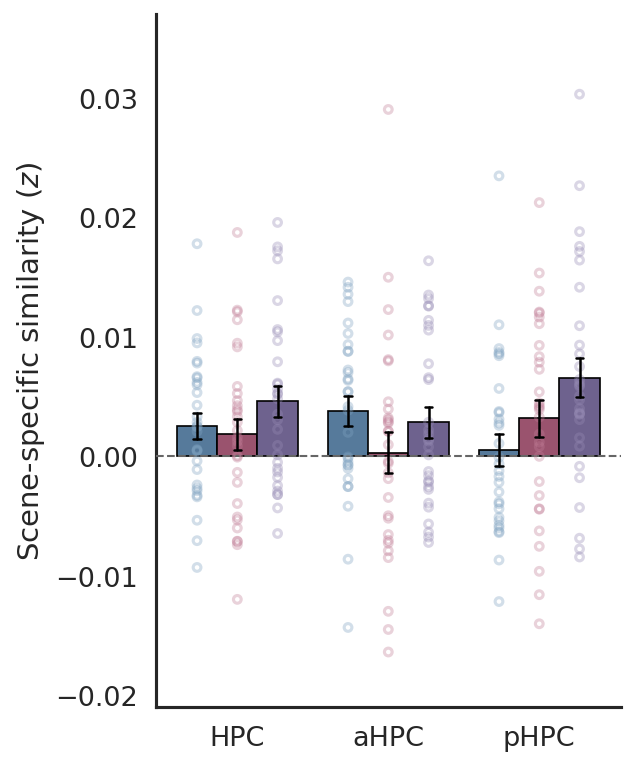

In [36]:
ax = plot_roi_correlations(
    df=df_difference,
    roi_order=["HPC", "aHPC", "pHPC"],
    condition_order=["A-A", "V-V","C-C"],
    custom_legend_labels=["Auditory", "Visual", "Congruent"],
    palette=['#4a7ba7', '#a6476b', '#6b5b95', '#4a7ba7', '#a6476b'],
    alpha=[1, 1, 1, 1, 1],
    show_points=True,
    ylim=(-0.021, .037),
    point_alpha=.35,
    y_col='z_similarity',
    point_size=1.2,
    point_lightness=0.3,
    figure_width=4,
    show_legend=False,
    condition_offsets={'C-C': 0},
)
plt.savefig('Hipppocampus_RSA_main.svg', dpi=300, bbox_inches='tight')
# plt.show()

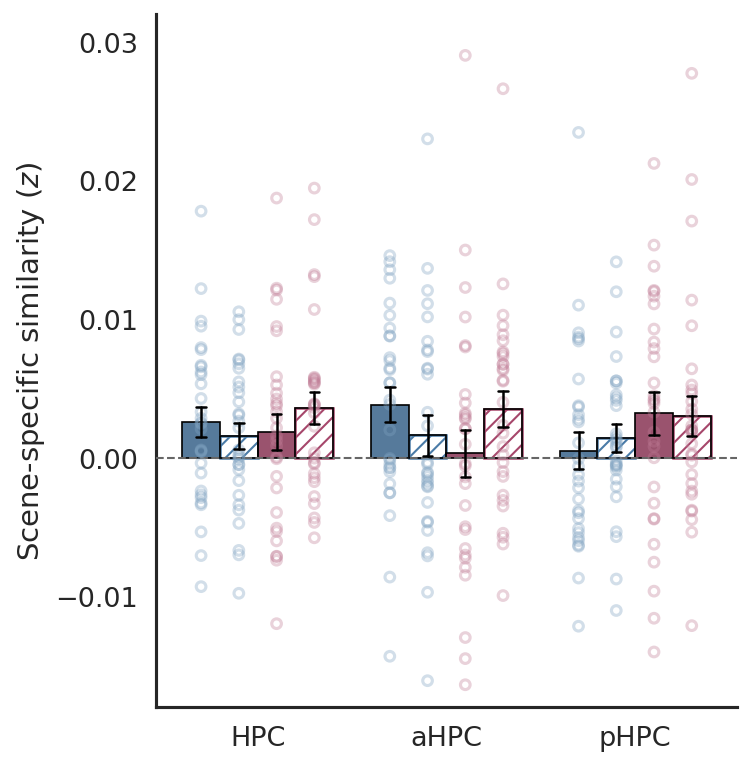

In [37]:
ax = plot_roi_correlations(
    df=df_difference,
    roi_order=["HPC", "aHPC", "pHPC"],
    condition_order=["A-A", "A-IC_A","V-V", "V-IC_V"],
    custom_legend_labels=["Auditory", "Incongruent Auditory","Visual", "Incongruent Visual"],
    palette=['#4a7ba7', '#4a7ba7', '#a6476b', '#a6476b'],
    alpha=[1, 1, 1, 1, 1],
    show_points=True,
    ylim=(-0.018, .032),
    point_alpha=.35,
    point_size=2,
    point_lightness=0.3,
    y_col='z_similarity',
    hatch_conditions=["A-IC_A", "V-IC_V"],
    figure_width=5,# 4 for paper, 5 for poster
    show_legend=False
)

plt.savefig('labels_hippocampus_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()

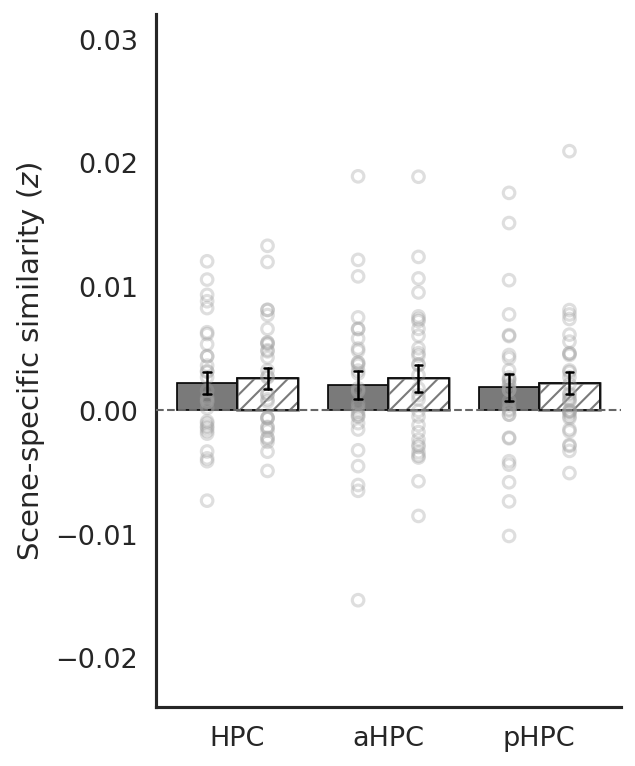

In [15]:
ax = plot_roi_correlations(
    df=df_difference,
    roi_order=["HPC", "aHPC", "pHPC"],
    condition_order=["unisensory_mean", "IC_mean"],
    custom_legend_labels=["Auditory", "Incongruent Auditory","Visual", "Incongruent Visual"],
    palette=['#7a7a7a', '#7a7a7a'],
    alpha=[1, 1, 1, 1, 1],
    show_points=True,
    ylim=(-0.024, .032),
    point_alpha=.35,
    point_size=1.2,
    point_lightness=0.3,
    y_col='z_similarity',
    hatch_conditions=["IC_mean"],
    figure_width=4,# 4 for paper, 5 for poster
    show_legend=False
)

plt.savefig('incongruent_hippocampus_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()

# Plot RSA main conditions in hippocampal subfields

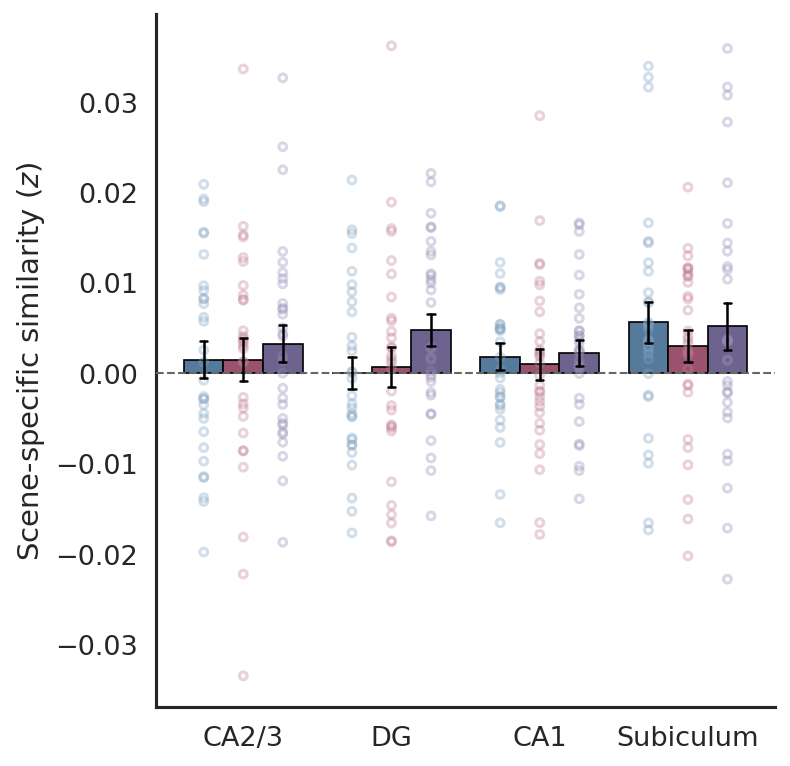

In [40]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["CA2/3", "DG", "CA1", "Subiculum"],
 condition_order=["A-A", "V-V", "C-C"],
 custom_legend_labels=["Auditory", "Visual"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95', '#4a7ba7', '#a6476b'],
 #ylim=(-0.021, .037),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=1.2,       # Point size
 point_lightness=0.3,
 y_col='z_similarity',
 figure_width=5.33,  # 4.5 × (4/3) = 6
 show_legend=False,
)
plt.savefig('labels_subfields_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()


⚠ WARNING: Data points outside y-axis limits:
  • CA2/3 - V-V: 2 point(s) below -0.0200
  • Subiculum - V-V: 1 point(s) below -0.0200



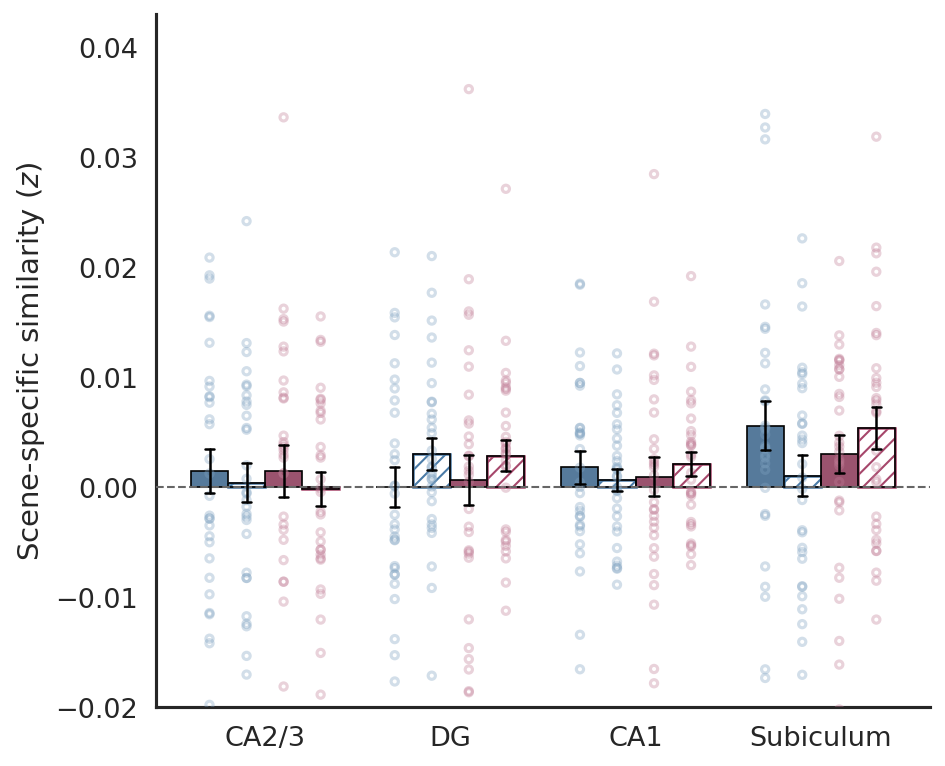

In [10]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["CA2/3", "DG", "CA1", "Subiculum"],
 condition_order=["A-A", "A-IC_A","V-V", "V-IC_V"],
 custom_legend_labels=["Auditory", "Incongruent Auditory","Visual", "Incongruent Visual"],
 palette=['#4a7ba7', '#4a7ba7', '#a6476b', '#a6476b'],
 ylim=(-0.02, .043),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=1.5,       # Point size
 point_lightness=0.3,
 hatch_conditions=["A-IC_A", "V-IC_V"],
 y_col='z_similarity',
 figure_width=6.66,# 6.66 for poster, 5.33 for paper
 show_legend=False
)
plt.savefig('labels_subfields_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()

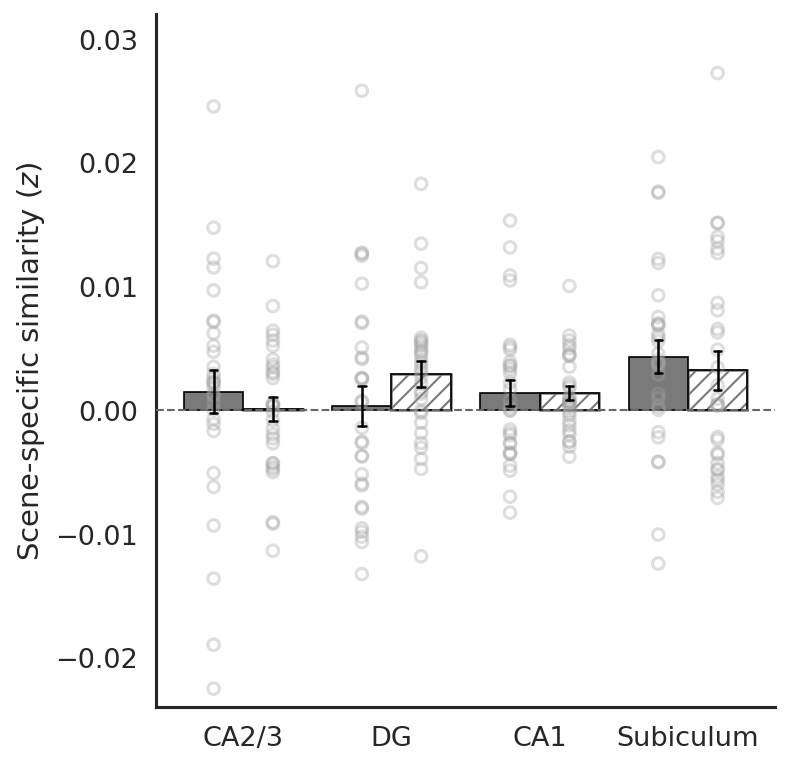

In [27]:
ax = plot_roi_correlations(
    df=df_difference,
    roi_order=["CA2/3", "DG", "CA1", "Subiculum"],
    condition_order=["unisensory_mean", "IC_mean"],
    custom_legend_labels=["mean(Unisensory)", "mean(Incongruent)"],
    palette=['#7a7a7a', '#7a7a7a'],
    alpha=[1, 1, 1, 1, 1],
    show_points=True,
    ylim=(-0.024, .032),
    point_alpha=.35,
    point_size=1.2,
    point_lightness=0.3,
    y_col='z_similarity',
    hatch_conditions=["IC_mean"],
    figure_width=5.33,# 4 for paper, 5 for poster
    show_legend=False
)

plt.savefig('incongrunt_subfields_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()

# Plot RSA main conditions in extrahippocampal subregions

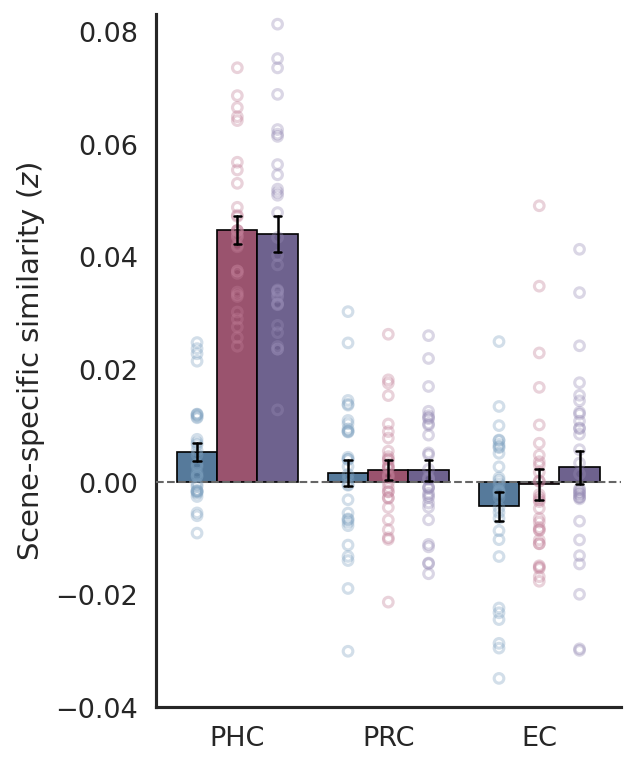

In [39]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["PHC","PRC", "EC"],
 condition_order=["A-A", "V-V","C-C"],
 custom_legend_labels=["Auditory", "Visual", "Congruent"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95', '#4a7ba7', '#a6476b'],
 ylim=(-0.04, .083),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=1.5,       # Point size
 point_lightness=0.3,
 y_col='z_similarity',
 figure_width=4,
 show_legend=False
)
plt.savefig('extrahipp_main.svg', dpi=300, bbox_inches='tight')
# plt.show()

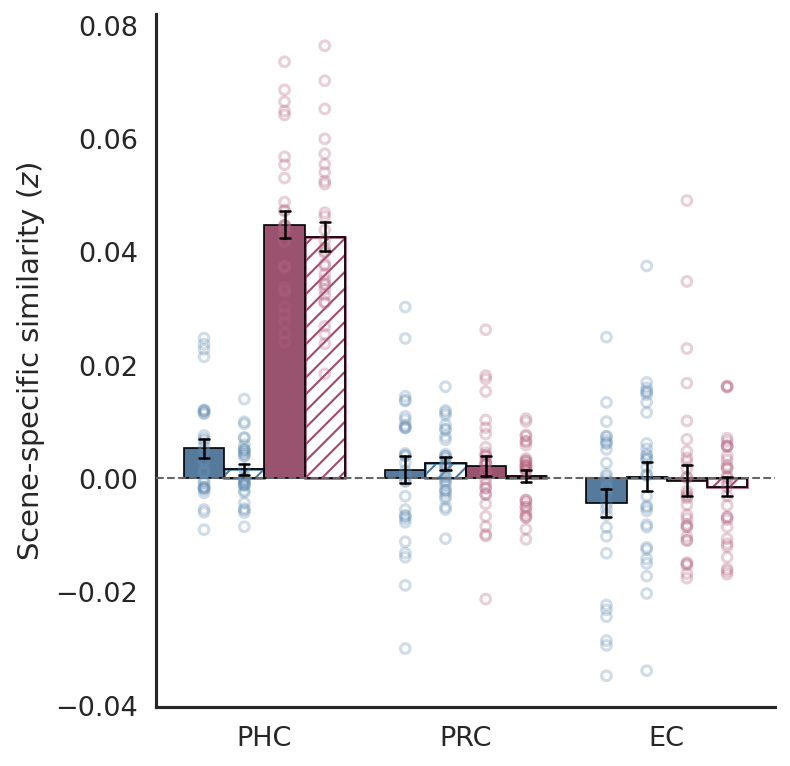

In [12]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["PHC", "PRC", "EC"],
 condition_order=["A-A", "A-IC_A","V-V", "V-IC_V"],
 custom_legend_labels=["Auditory", "Incongruent - Audio","Visual", "Incongruent - Visual"],
 palette=['#4a7ba7', '#4a7ba7', '#a6476b', '#a6476b'], # brighter same colors: ['#c1527d', '#5a8ec2', '#7d6bb0','#c1527d', '#5a8ec2']
 alpha=[1, 1, 1, 1, 1],
 #ylim=(-0.04, .08),
 show_points=True,  # Show individual data points
 point_alpha=0.3,   # Semi-transparent points
 point_size=2,       # Point size
 hatch_conditions=["A-IC_A", "V-IC_V"],
 figure_width=5.33,
 y_col='z_similarity',
 show_legend=False
)
plt.savefig('extra_incon.pdf', dpi=300, bbox_inches='tight')
# plt.show()

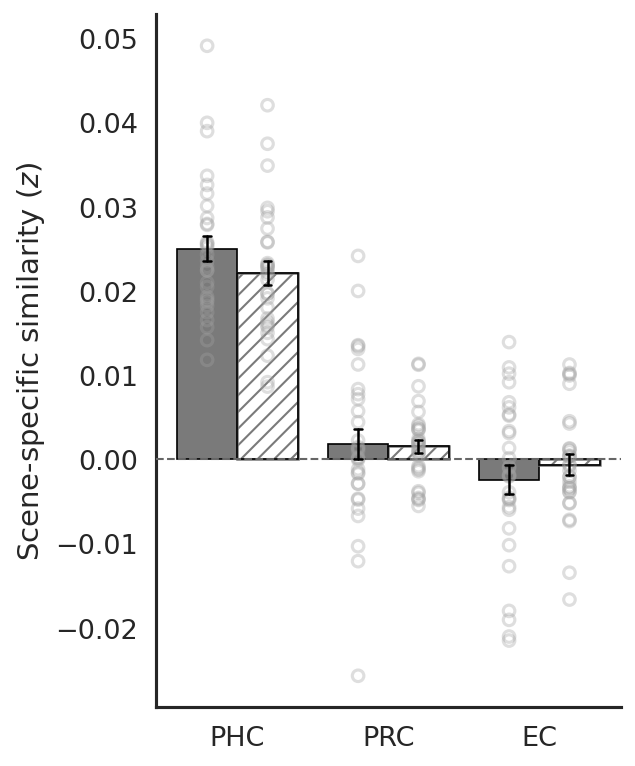

In [18]:
ax = plot_roi_correlations(
    df=df_difference,
    roi_order=["PHC", "PRC", "EC"],
    condition_order=["unisensory_mean", "IC_mean"],
    custom_legend_labels=["mean(Unisensory)", "mean(Incongruent)"],
    palette=['#7a7a7a', '#7a7a7a'],
    alpha=[1, 1, 1, 1, 1],
    show_points=True,
    #ylim=(-0.022, .051),
    point_alpha=.35,
    point_size=1.2,
    point_lightness=0.3,
    y_col='z_similarity',
    hatch_conditions=["IC_mean"],
    figure_width=4,# 4 for paper, 5 for poster
    show_legend=False
)

plt.savefig('labels_hippocampus_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()


⚠ WARNING: Data points outside y-axis limits:
  • OP - A-A: 1 point(s) below -0.0800
  • LOC - A-A: 2 point(s) above 0.1700
  • LOC - V-V: 3 point(s) above 0.1700
  • LOC - C-C: 1 point(s) above 0.1700



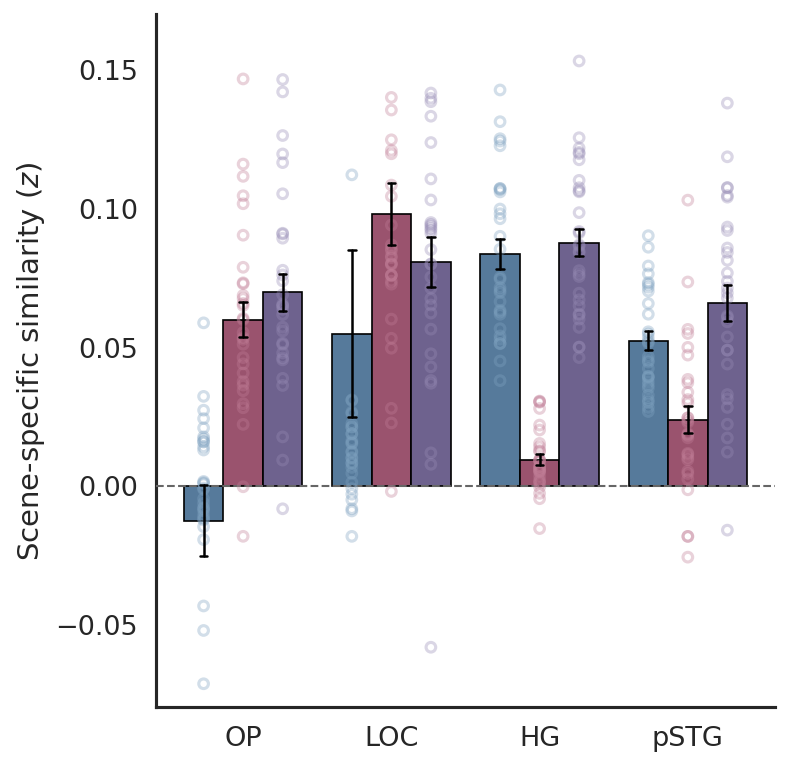

In [15]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["OP", "LOC", "HG", "pSTG"],
 condition_order=["A-A", "V-V","C-C"],
 custom_legend_labels=["Auditory", "Visual", "Congruent"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95', '#4a7ba7', '#a6476b'],
 ylim=(-0.08, .17),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=1.5,       # Point size
 point_lightness=0.3,
 figure_width=5.33,
 y_col='z_similarity',
 show_legend=False
)
plt.savefig('cortical_main.svg', dpi=300, bbox_inches='tight')
# plt.show()


⚠ WARNING: Data points outside y-axis limits:
  • OP - A-A: 1 point(s) below -0.1000
  • OP - V-IC_V: 1 point(s) below -0.1000
  • LOC - A-A: 2 point(s) above 0.2100
  • LOC - A-IC_A: 1 point(s) below -0.1000
  • LOC - A-IC_A: 1 point(s) above 0.2100
  • LOC - V-V: 3 point(s) above 0.2100
  • LOC - V-IC_V: 1 point(s) below -0.1000



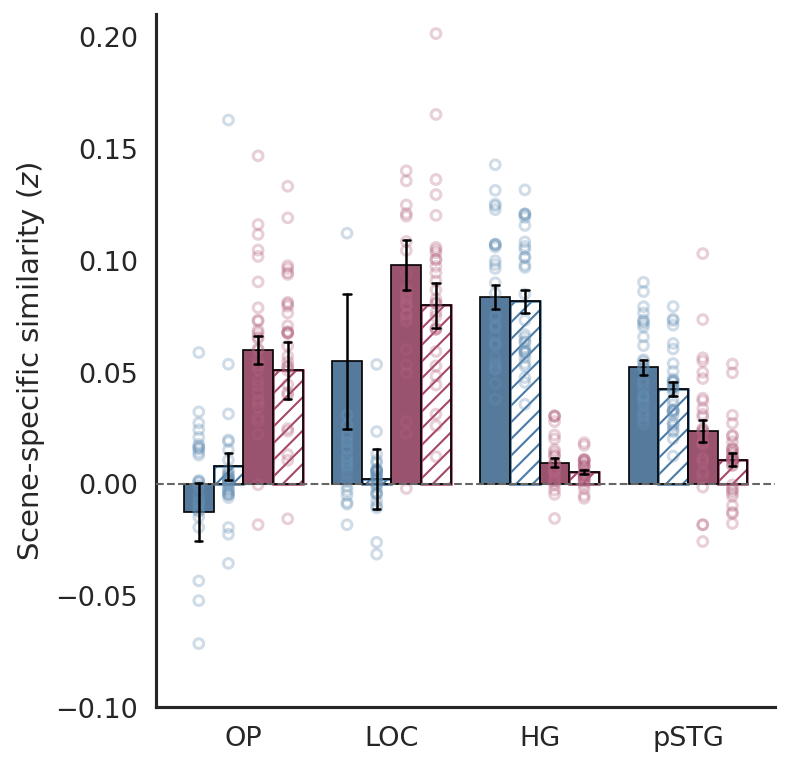

In [14]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["OP", "LOC", "HG", "pSTG"],
 condition_order=["A-A", "A-IC_A","V-V", "V-IC_V"],
 custom_legend_labels=["Auditory", "Incongruent - Audio","Visual", "Incongruent - Visual"],
 palette=['#4a7ba7', '#4a7ba7', '#a6476b', '#a6476b'], # brighter same colors: ['#c1527d', '#5a8ec2', '#7d6bb0','#c1527d', '#5a8ec2']
 ylim=(-0.1, .21),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=0.3,   # Semi-transparent points
 point_size=2,       # Point size
 hatch_conditions=["A-IC_A", "V-IC_V"],
 figure_width=5.33,
 y_col='z_similarity',
 show_legend=False
)
plt.savefig('cortical_incon.pdf', dpi=300, bbox_inches='tight')
# plt.show()


⚠ WARNING: Data points outside y-axis limits:
  • OP - unisensory_mean: 1 point(s) below -0.1200
  • LOC - unisensory_mean: 2 point(s) above 0.1750



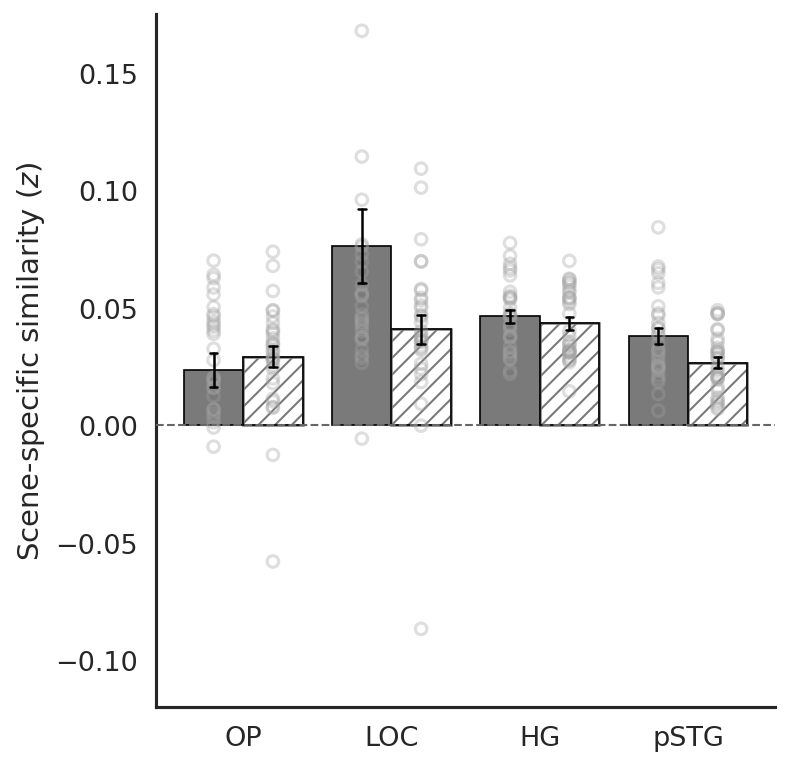

In [28]:
ax = plot_roi_correlations(
    df=df_difference,
    roi_order=["OP", "LOC", "HG", "pSTG"],
    condition_order=["unisensory_mean", "IC_mean"],
    custom_legend_labels=["mean(Unisensory)", "mean(Incongruent)"],
    palette=['#7a7a7a', '#7a7a7a'],
    alpha=[1, 1, 1, 1, 1],
    show_points=True,
    ylim=(-0.12, .175),
    point_alpha=.35,
    point_size=1.2,
    point_lightness=0.3,
    y_col='z_similarity',
    hatch_conditions=["IC_mean"],
    figure_width=5.33,# 4 for paper, 5 for poster
    show_legend=False
)

plt.savefig('corticals_hippocampus_RSA_MainConds.svg', dpi=300, bbox_inches='tight')
# plt.show()

# Run one-way permutation tests for main conditions

In [6]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V","C-C", "A-IC_A", "V-IC_V", "IC_A-IC_A", "IC_V-IC_V"],
    rois=["HPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: HPC (1/1)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,HPC,A-A,0.002572,0.001090,30,0.0138,greater,True,0.0138,True,1
3,HPC,A-IC_A,0.001561,0.000951,30,0.0519,greater,False,0.0519,False,1
2,HPC,C-C,0.004616,0.001305,30,0.0006,greater,True,0.0006,True,1
5,HPC,IC_A-IC_A,-0.001602,0.001007,30,0.9376,greater,False,0.9376,False,1
6,HPC,IC_V-IC_V,0.004020,0.001433,30,0.0028,greater,True,0.0028,True,1
4,HPC,V-IC_V,0.003587,0.001143,30,0.0015,greater,True,0.0015,True,1
1,HPC,V-V,0.001849,0.001278,30,0.0845,greater,False,0.0845,False,1


In [8]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V","C-C", "A-IC_A", "V-IC_V", "IC_A-IC_A", "IC_V-IC_V"],
    rois=["aHPC", "pHPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: aHPC (1/2)
Processing ROI: pHPC (2/2)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,aHPC,A-A,0.003815,0.001266,30,0.0029,greater,True,0.0058,True,2
3,aHPC,A-IC_A,0.001637,0.001471,30,0.1305,greater,False,0.1305,False,2
2,aHPC,C-C,0.002867,0.001292,30,0.0171,greater,True,0.0171,True,2
5,aHPC,IC_A-IC_A,-0.001839,0.001445,30,0.8876,greater,False,0.8876,False,2
6,aHPC,IC_V-IC_V,0.003334,0.001377,30,0.0113,greater,True,0.0226,True,2
4,aHPC,V-IC_V,0.003536,0.001312,30,0.0043,greater,True,0.0086,True,2
1,aHPC,V-V,0.000314,0.001704,30,0.4329,greater,False,0.4329,False,2
7,pHPC,A-A,0.000509,0.001334,30,0.3499,greater,False,0.3499,False,2
10,pHPC,A-IC_A,0.001418,0.000997,30,0.0835,greater,False,0.1305,False,2
9,pHPC,C-C,0.006599,0.001645,30,0.0001,greater,True,0.0002,True,2


In [9]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V","C-C"],
    rois=["CA1", "CA2/3", "DG", "Subiculum"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: CA1 (1/4)
Processing ROI: CA2/3 (2/4)
Processing ROI: DG (3/4)
Processing ROI: Subiculum (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,CA1,A-A,0.001831,0.001487,30,0.1130,greater,False,0.2260,False,4
2,CA1,C-C,0.002275,0.001440,30,0.0645,greater,False,0.0651,False,4
1,CA1,V-V,0.000963,0.001760,30,0.3036,greater,False,0.3752,False,4
3,CA2/3,A-A,0.001500,0.002016,30,0.2244,greater,False,0.2992,False,4
5,CA2/3,C-C,0.003266,0.002047,30,0.0651,greater,False,0.0651,False,4
4,CA2/3,V-V,0.001506,0.002348,30,0.2631,greater,False,0.3752,False,4
6,DG,A-A,0.000021,0.001802,30,0.4889,greater,False,0.4889,False,4
8,DG,C-C,0.004801,0.001799,30,0.0053,greater,True,0.0212,True,4
7,DG,V-V,0.000672,0.002243,30,0.3752,greater,False,0.3752,False,4
9,Subiculum,A-A,0.005608,0.002261,30,0.0095,greater,True,0.0380,True,4


In [31]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V","C-C"],
    rois=["PHC", "PRC", "EC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: PHC (1/3)
Processing ROI: PRC (2/3)
Processing ROI: EC (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
6,EC,A-A,-0.004360,0.002538,30,0.9545,greater,False,0.9545,False,3
8,EC,C-C,0.002605,0.002922,30,0.1875,greater,False,0.1875,False,3
7,EC,V-V,-0.000451,0.002753,30,0.5675,greater,False,0.5675,False,3
0,PHC,A-A,0.005312,0.001658,30,0.0015,greater,True,0.0045,True,3
2,PHC,C-C,0.044000,0.003229,30,0.0000,greater,True,0.0000,True,3
1,PHC,V-V,0.044747,0.002429,30,0.0000,greater,True,0.0000,True,3
3,PRC,A-A,0.001531,0.002312,30,0.2578,greater,False,0.3867,False,3
5,PRC,C-C,0.002050,0.001930,30,0.1493,greater,False,0.1875,False,3
4,PRC,V-V,0.002155,0.001728,30,0.1060,greater,False,0.1590,False,3


In [46]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V","C-C"],
    rois=["OP", "LOC", "HG", "pSTG"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: OP (1/4)
Processing ROI: LOC (2/4)
Processing ROI: HG (3/4)
Processing ROI: pSTG (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
6,HG,A-A,0.083519,0.005255,30,0.0000,greater,True,0.0000,True,4
8,HG,C-C,0.087580,0.004900,30,0.0000,greater,True,0.0000,True,4
7,HG,V-V,0.009369,0.001976,30,0.0000,greater,True,0.0000,True,4
3,LOC,A-A,0.054760,0.030119,30,0.0000,greater,True,0.0000,True,4
5,LOC,C-C,0.080777,0.008987,30,0.0000,greater,True,0.0000,True,4
4,LOC,V-V,0.097983,0.011265,30,0.0000,greater,True,0.0000,True,4
0,OP,A-A,-0.012653,0.012931,30,0.7678,greater,False,0.7678,False,4
2,OP,C-C,0.069707,0.006702,30,0.0000,greater,True,0.0000,True,4
1,OP,V-V,0.059799,0.006320,30,0.0000,greater,True,0.0000,True,4
9,pSTG,A-A,0.052218,0.003358,30,0.0000,greater,True,0.0000,True,4


# Compute RSA multisensory facilitation and run permutation tests

In [6]:
facilitation_data = calculate_facilitation(df_difference)

In [7]:
results_df_facilitation = run_permutation_test(
    facilitation_data, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_V", "C_v_A"],
    rois=["HPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_facilitation)

Processing ROI: HPC (1/1)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
1,HPC,C_v_A,0.002044,0.001816,30,0.1324,greater,False,0.1324,False,1
0,HPC,C_v_V,0.002767,0.001625,30,0.0500,greater,False,0.0500,True,1


In [9]:
results_df_facilitation = run_permutation_test(
    facilitation_data, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_V", "C_v_A"],
    rois=["pHPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_facilitation)

Processing ROI: pHPC (1/1)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
1,pHPC,C_v_A,0.006090,0.002185,30,0.0030,greater,True,0.0030,True,1
0,pHPC,C_v_V,0.003392,0.001762,30,0.0317,greater,True,0.0317,True,1


In [10]:
results_df_facilitation = run_permutation_test(
    facilitation_data, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_V", "C_v_A"],
    rois=["CA1", "CA2/3", "DG"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_facilitation)

Processing ROI: CA1 (1/3)
Processing ROI: CA2/3 (2/3)
Processing ROI: DG (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
1,CA1,C_v_A,0.000444,0.001803,30,0.3994,greater,False,0.3994,False,3
0,CA1,C_v_V,0.001311,0.002212,30,0.2786,greater,False,0.2945,False,3
3,CA2/3,C_v_A,0.001765,0.002861,30,0.2750,greater,False,0.3994,False,3
2,CA2/3,C_v_V,0.001760,0.003326,30,0.2945,greater,False,0.2945,False,3
5,DG,C_v_A,0.004780,0.002145,30,0.0187,greater,True,0.0561,False,3
4,DG,C_v_V,0.004130,0.002811,30,0.0835,greater,False,0.2505,False,3


In [11]:
results_df_facilitation = run_permutation_test(
    facilitation_data, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_V", "C_v_A"],
    rois=["PHC", "PRC", "EC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_facilitation)

Processing ROI: PHC (1/3)
Processing ROI: PRC (2/3)
Processing ROI: EC (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
5,EC,C_v_A,0.006964,0.003792,30,0.0363,greater,True,0.05445,False,3
4,EC,C_v_V,0.003055,0.004649,30,0.2530,greater,False,0.63220,False,3
1,PHC,C_v_A,0.038689,0.003420,30,0.0000,greater,True,0.00000,True,3
0,PHC,C_v_V,-0.000747,0.002360,30,0.6322,greater,False,0.63220,False,3
3,PRC,C_v_A,0.000519,0.002996,30,0.4357,greater,False,0.43570,False,3
2,PRC,C_v_V,-0.000105,0.002259,30,0.5173,greater,False,0.63220,False,3


In [54]:
results_df_facilitation = run_permutation_test(
    facilitation_data, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_mean_pure_AV", "mean_pure_AV_v_mean_incongruent", "C_v_V", "C_v_A"],
    rois=["OP","HG", "pSTG"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_facilitation)

Processing ROI: OP (1/3)
Processing ROI: HG (2/3)
Processing ROI: pSTG (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
7,HG,C_v_A,0.004060,0.002215,30,0.0355,greater,True,0.03550,True,3
6,HG,C_v_V,0.078210,0.005197,30,0.0000,greater,True,0.00000,True,3
4,HG,C_v_mean_pure_AV,0.041135,0.002796,30,0.0000,greater,True,0.00000,True,3
5,HG,mean_pure_AV_v_mean_incongruent,0.003045,0.001290,30,0.0104,greater,True,0.01560,True,3
3,OP,C_v_A,0.082359,0.016007,30,0.0000,greater,True,0.00000,True,3
2,OP,C_v_V,0.009908,0.005492,30,0.0409,greater,True,0.04090,True,3
0,OP,C_v_mean_pure_AV,0.046133,0.009641,30,0.0000,greater,True,0.00000,True,3
1,OP,mean_pure_AV_v_mean_incongruent,-0.005725,0.006481,30,0.7748,greater,False,0.77480,False,3
11,pSTG,C_v_A,0.013738,0.004922,30,0.0057,greater,True,0.00855,True,3
10,pSTG,C_v_V,0.042229,0.005803,30,0.0000,greater,True,0.00000,True,3


# Plot A-V (cross-condition) results

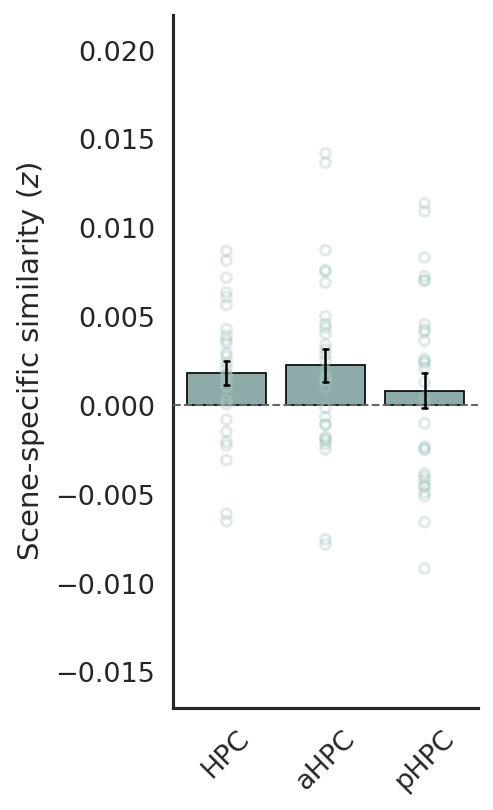

In [46]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["HPC", "aHPC", "pHPC"],
 condition_order=["V-A"],
 custom_legend_labels=["V-A: Cross-Condition"],
 palette=['#87b0ad'],
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 ylim=(-0.017, .022),
 point_size=.5,       # Point size
 point_lightness=0.25,
 figure_width=2.625, # 3.28 for poster, 2.625 for paper
 y_col = 'z_similarity',
 show_legend=False,
 x_label_rotation=45
            )
plt.savefig('Hipp_Cross_Condition.svg', dpi=300, bbox_inches='tight')
# plt.show()

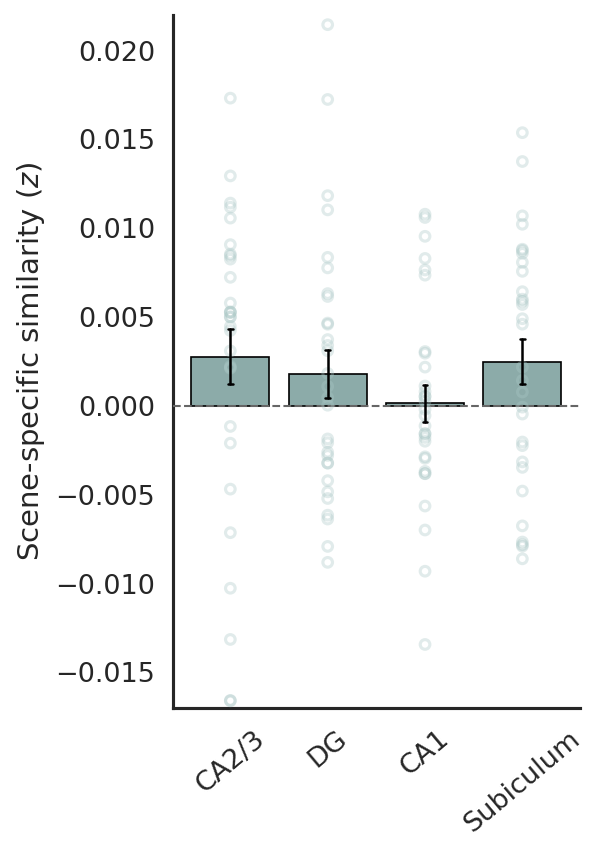

In [47]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["CA2/3", "DG", "CA1", "Subiculum"],
 condition_order=["V-A"],
 custom_legend_labels=["V-A: Cross-Condition"],
 palette=['#87b0ad'],
 ylim=(-0.017, .022),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=.5,       # Point size
 point_lightness=0.3,
 figure_width=3.5,# 4.375 for poster, 3.5 for paper
 show_legend=False,
 x_label_rotation=40,
    y_col='z_similarity'
            )
plt.savefig('Subfields_Cross_Condition.svg', dpi=300, bbox_inches='tight')
# plt.show()

findfont: Font family ['cursive'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'cursive' not found because none of the following families were found: Apple Chancery, Textile, Zapf Chancery, Sand, Script MT, Felipa, Comic Neue, Comic Sans MS, cursive
findfont: Font family ['Liberation Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Liberation Sans'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Liberation Sans'] not found. Falling back to DejaVu Sans.


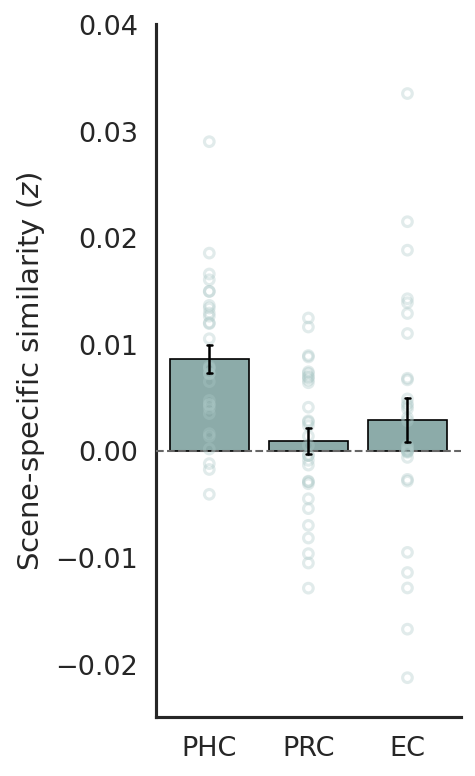

In [7]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["PHC", "PRC", "EC"],
 condition_order=["V-A"],
 custom_legend_labels=["V-A: Cross-Condition"],
 palette=['#87b0ad'],
 ylim=(-0.025, .04),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=.5,       # Point size
 point_lightness=0.3,
 y_col = 'z_similarity',
 figure_width=2.625,
 show_legend=False,
            )
plt.savefig('extra_cross.svg', dpi=300, bbox_inches='tight')
# plt.show()


⚠ WARNING: Data points outside y-axis limits:
  • OP - V-A: 1 point(s) below -0.0250
  • OP - V-A: 2 point(s) above 0.0400
  • LOC - V-A: 1 point(s) below -0.0250
  • LOC - V-A: 2 point(s) above 0.0400



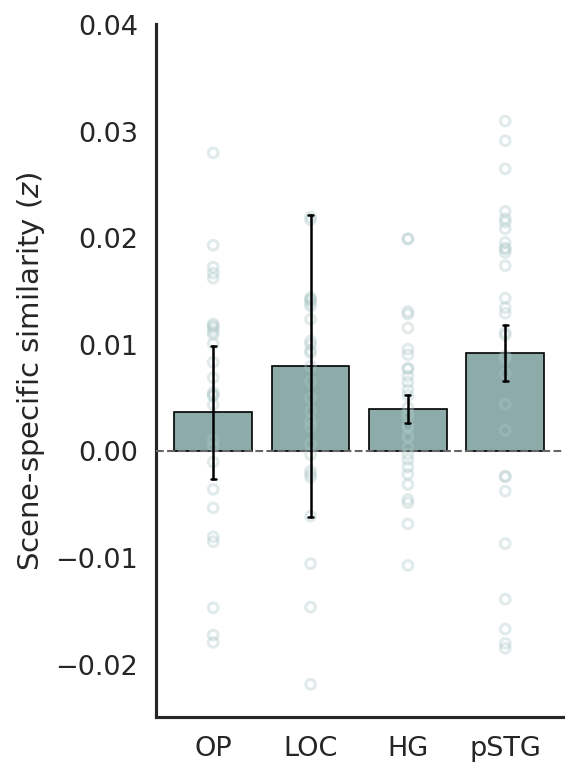

In [11]:
ax = plot_roi_correlations(
 df=df_difference,
 roi_order=["OP", "LOC", "HG", "pSTG"],
 condition_order=["V-A"],
 custom_legend_labels=["V-A: Cross-Condition"],
 palette=['#87b0ad'],
 ylim=(-0.025, .04),
 alpha=[1, 1, 1, 1, 1],
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=.5,       # Point size
 point_lightness=0.3,
 figure_width=3.5,
 y_col = 'z_similarity',
 show_legend=False,
            )
plt.savefig('cortical_cross.pdf', dpi=300, bbox_inches='tight')
# plt.show()

In [31]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["V-A"], #["A-A", "A-IC_A", "V-V", "V-IC_V", "C-C", 'V-A'],
    rois=["HPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: HPC (1/1)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,HPC,V-A,0.001825,0.000681,30,0.0064,greater,True,0.0064,True,1


In [32]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["V-A"], #["A-A", "A-IC_A", "V-V", "V-IC_V", "C-C", 'V-A'],
    rois=["aHPC", "pHPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: aHPC (1/2)
Processing ROI: pHPC (2/2)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,aHPC,V-A,0.002255,0.000927,30,0.0085,greater,True,0.0170,True,2
1,pHPC,V-A,0.000837,0.000976,30,0.1963,greater,False,0.1963,False,2


In [33]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["V-A"], #["A-A", "A-IC_A", "V-V", "V-IC_V", "C-C", 'V-A'],
    rois=["CA1", "CA2/3", "DG", "Subiculum"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: CA1 (1/4)
Processing ROI: CA2/3 (2/4)
Processing ROI: DG (3/4)
Processing ROI: Subiculum (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,CA1,V-A,0.000138,0.001043,30,0.4534,greater,False,0.453400,False,4
1,CA2/3,V-A,0.002764,0.001548,30,0.0445,greater,True,0.089000,False,4
2,DG,V-A,0.001784,0.001332,30,0.0989,greater,False,0.131867,False,4
3,Subiculum,V-A,0.002484,0.001251,30,0.0303,greater,True,0.089000,False,4


In [34]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_difference, 
    analysis_col="z_similarity",
    group_cols=["roi", "cond"],
    conditions=["V-A"], #["A-A", "A-IC_A", "V-V", "V-IC_V", "C-C", 'V-A'],
    rois=["PHC", "PRC", "EC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: PHC (1/3)
Processing ROI: PRC (2/3)
Processing ROI: EC (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
2,EC,V-A,0.002848,0.002062,30,0.0899,greater,False,0.13485,False,3
0,PHC,V-A,0.008610,0.001300,30,0.0000,greater,True,0.00000,True,3
1,PRC,V-A,0.000899,0.001230,30,0.2380,greater,False,0.23800,False,3


In [14]:
# ONE-WAY STATISTICS (Main Conditions!)
main_cond_results = run_permutation_test(
    df_result, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["V-A"], #["A-A", "A-IC_A", "V-V", "V-IC_V", "C-C", 'V-A'],
    rois=["OP", "LOC", "HG", "pSTG"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)
show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(main_cond_results)

Processing ROI: OP (1/4)
Processing ROI: LOC (2/4)
Processing ROI: HG (3/4)
Processing ROI: pSTG (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
2,HG,V-A,0.004332,0.001201,30,0.0008,greater,True,0.0018,True,4
1,LOC,V-A,0.006120,0.004817,30,0.1128,greater,False,0.1462,False,4
0,OP,V-A,0.003611,0.003282,30,0.1462,greater,False,0.1462,False,4
3,pSTG,V-A,0.008755,0.002483,30,0.0009,greater,True,0.0018,True,4


# Load GLM Data

In [5]:
import pandas as pd
import glob

# Fix the glob pattern - add / and .csv extension
data_dir = "/gpfs/milgram/scratch60/turk-browne/or62/sandbox/GLM_structs/results/"
file_pattern = f"{data_dir}beta_activations_subs*.csv"

# Check what files are found
files_found = glob.glob(file_pattern)
print(f"Found {len(files_found)} files:")

# Combine all CSV files
if files_found:
    GLM_results = pd.concat([pd.read_csv(f) for f in files_found], ignore_index=True)
    print(f"Combined shape: {GLM_results.shape}")
    
    # Your existing processing
    #df_pivot = RSA_results.pivot_table(index=["cond", "sub", "roi"], columns="type", values="corr").reset_index()
    #df_pivot["corr_diff"] = df_pivot["diag"] - df_pivot["off_diag"]
    #df_result = df_pivot[["cond", "sub", "roi", "corr_diff"]].copy()
    
else:
    print("No CSV files found! Check the file pattern.")

GLM_results['roi'] = GLM_results['roi'].replace("ant_combined_HPC_mask_T1", "aHPC")
GLM_results['roi'] = GLM_results['roi'].replace("post_combined_HPC_mask_T1", "pHPC")
GLM_results['roi'] = GLM_results['roi'].replace("ant_left_HPC_mask_T1", "left_anterior")
GLM_results['roi'] = GLM_results['roi'].replace("post_left_HPC_mask_T1", "left_posterior")
GLM_results['roi'] = GLM_results['roi'].replace("ant_right_HPC_mask_T1", "right_anterior")
GLM_results['roi'] = GLM_results['roi'].replace("post_right_HPC_mask_T1", "right_posterior")
GLM_results['roi'] = GLM_results['roi'].replace("right_HPC", "R. Hippocampus")
GLM_results['roi'] = GLM_results['roi'].replace("left_HPC", "L. Hippocampus")
GLM_results['roi'] = GLM_results['roi'].replace("combined_HPC", "HPC")
GLM_results['roi'] = GLM_results['roi'].replace("CA2+3", "CA2/3")
GLM_results['roi'] = GLM_results['roi'].replace("Lateral Occipital Cortex, inferior division", "LOC")
GLM_results['roi'] = GLM_results['roi'].replace("STG_P", "pSTG")



GLM_results['cond'] = GLM_results['cond'].replace("audio", "A-A")
GLM_results['cond'] = GLM_results['cond'].replace("visual", "V-V")
GLM_results['cond'] = GLM_results['cond'].replace("congruent", "C-C")


# Save the pivot table with all info
output_dir = data_dir
GLM_results.to_csv(f"{output_dir}GLM_results_all.csv", index=False)

Found 30 files:
Combined shape: (2400, 4)


In [49]:
show_results = False
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(GLM_results)

# Plot GLM main conditions in whole-hippocampus

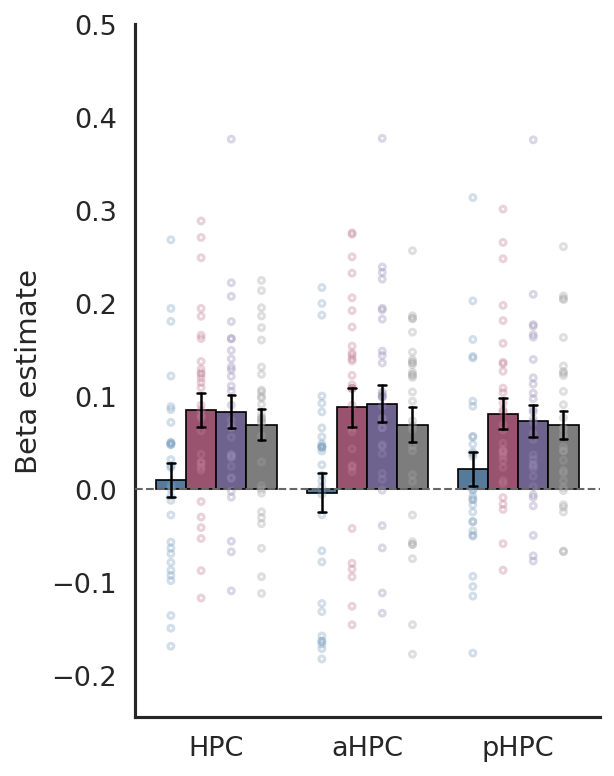

In [64]:
ax = plot_roi_correlations(
 df=GLM_results,
 roi_order=["HPC", "aHPC", "pHPC"],
 condition_order=["A-A", "V-V","C-C", "incongruent"],
 custom_legend_labels=["Auditory", "Visual", "Congruent", "Incongruent"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95','#7d7d7d'],
 ylim=(-0.245, .5),
 alpha=[1, 1, 1, 1, 1],
 y_col='corr',
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=1.2,       # Point size
 point_lightness=0.3,
 figure_width=4,
 show_legend=False,
 ylabel=r"Beta estimate"
)
plt.savefig('glm_main_HCP.svg', dpi=300, bbox_inches='tight')
# plt.show()

# Plot GLM main conditions in hippocampal subfields

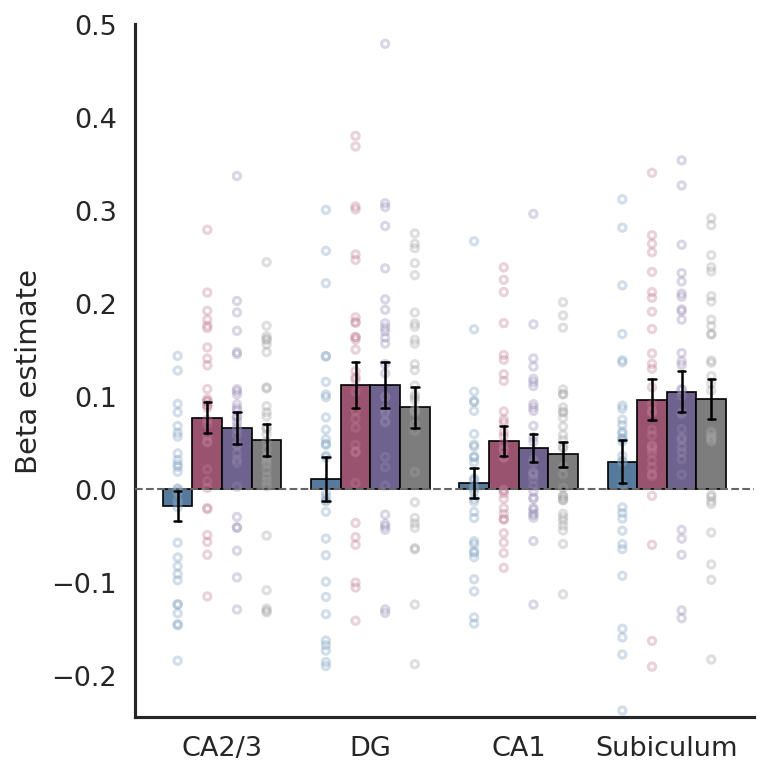

In [63]:
ax = plot_roi_correlations(
 df=GLM_results,
 roi_order=["CA2/3", "DG", "CA1", "Subiculum"],
 condition_order=["A-A", "V-V","C-C", "incongruent"],
 custom_legend_labels=["Auditory", "Visual", "Congruent", "Incongruent"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95','#7d7d7d'],
 ylim=(-0.245, .5),
 alpha=[1, 1, 1, 1, 1],
 y_col='corr',
 show_points=True,  # Show individual data points
 point_alpha=.35,   # Semi-transparent points
 point_size=1.5,       # Point size
 point_lightness=0.3,
 figure_width=5.33,
 show_legend=False,
 ylabel=r"Beta estimate"
)
plt.savefig('glm_main_subfields.svg', dpi=300, bbox_inches='tight')
# plt.show()


⚠ WARNING: Data points outside y-axis limits:
  • PHC - A-A: 3 point(s) below -0.2450
  • PHC - V-V: 3 point(s) above 0.5000
  • PHC - C-C: 3 point(s) above 0.5000
  • PHC - incongruent: 2 point(s) above 0.5000
  • PRC - A-A: 1 point(s) below -0.2450
  • EC - A-A: 5 point(s) below -0.2450
  • EC - V-V: 1 point(s) below -0.2450
  • EC - C-C: 2 point(s) below -0.2450
  • EC - C-C: 1 point(s) above 0.5000
  • EC - incongruent: 3 point(s) below -0.2450



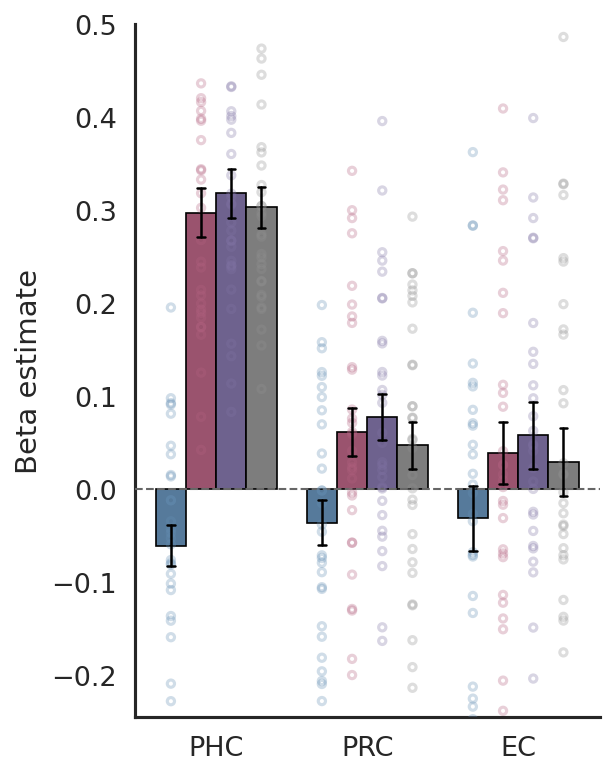

In [ ]:
ax = plot_roi_correlations(
 df=GLM_results,
 roi_order=["PHC", "PRC", "EC"],
 condition_order=["A-A", "V-V", "C-C", "incongruent"],
 custom_legend_labels=["Auditory",  "Visual", "Congruent", "Incongruent"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95','#7d7d7d'],
 #ylim=(-2.2, 5),
 alpha=[1, 1, 1, 1, 1],
 y_col='corr',
 show_points=True,  # Show individual data points
 point_alpha=0.3,   # Semi-transparent points
 point_size=1.5,       # Point size
 ylabel=r"Beta estimate",
 show_legend=False,   
 figure_width=4,
)
plt.savefig('glm_extra.svg', dpi=300, bbox_inches='tight')
# plt.show()

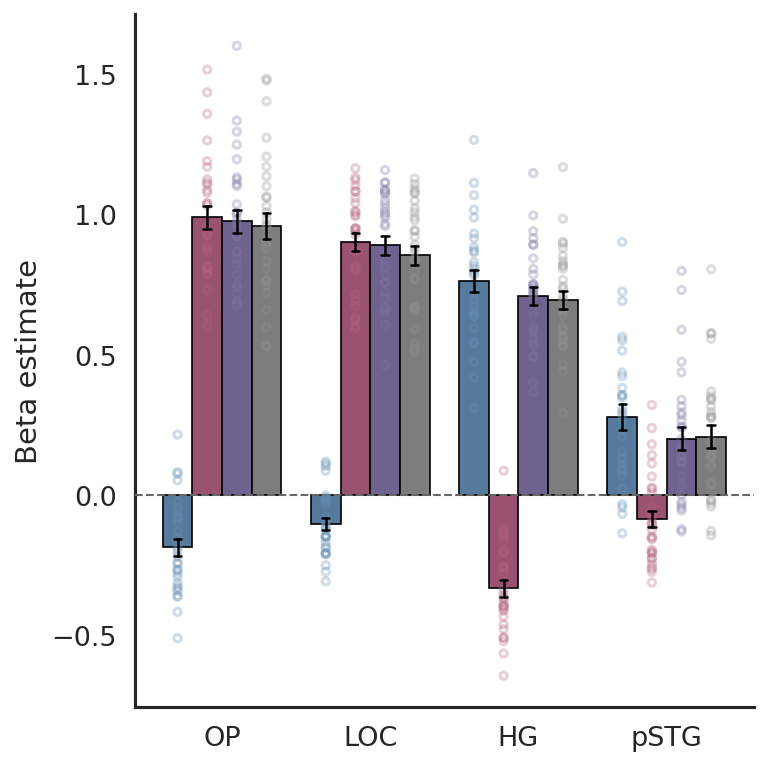

In [21]:
ax = plot_roi_correlations(
 df=GLM_results,
 roi_order=["OP", "LOC", "HG", "pSTG"],
 condition_order=["A-A", "V-V", "C-C", "incongruent"],
 custom_legend_labels=["Auditory",  "Visual", "Congruent", "Incongruent"],
 palette=['#4a7ba7', '#a6476b', '#6b5b95','#7d7d7d'],
 #ylim=(-2.2, 5),
 alpha=[1, 1, 1, 1, 1],
 y_col='corr',
 show_points=True,  # Show individual data points
 point_alpha=0.3,   # Semi-transparent points
 point_size=1.5,       # Point size
 ylabel=r"Beta estimate",
 show_legend=False,   
 figure_width=5.33,
)
plt.savefig('glm_extra.svg', dpi=300, bbox_inches='tight')
# plt.show()

In [6]:
results_df_glm = run_permutation_test(
    GLM_results, 
    analysis_col="corr",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V", "C-C", "incongruent"],
    rois=["HPC"],
    n_permutations=10000, 
    seed=42,
    test_type="two_tailed",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: HPC (1/1)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,HPC,A-A,0.009969,0.018664,30,0.6021,two_tailed,False,0.6021,False,1
2,HPC,C-C,0.083474,0.017807,30,0.0000,two_tailed,True,0.0000,True,1
1,HPC,V-V,0.085697,0.018360,30,0.0001,two_tailed,True,0.0001,True,1
3,HPC,incongruent,0.069693,0.016223,30,0.0001,two_tailed,True,0.0001,True,1


In [7]:
results_df_glm = run_permutation_test(
    GLM_results, 
    analysis_col="corr",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V", "C-C", "incongruent"],
    rois=["pHPC", "aHPC"],
    n_permutations=10000, 
    seed=42,
    test_type="two_tailed",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: pHPC (1/2)
Processing ROI: aHPC (2/2)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
4,aHPC,A-A,-0.003515,0.020903,30,0.8620,two_tailed,False,0.8620,False,2
6,aHPC,C-C,0.092312,0.019801,30,0.0000,two_tailed,True,0.0000,True,2
5,aHPC,V-V,0.088245,0.021250,30,0.0008,two_tailed,True,0.0008,True,2
7,aHPC,incongruent,0.069529,0.019067,30,0.0014,two_tailed,True,0.0014,True,2
0,pHPC,A-A,0.021721,0.018449,30,0.2566,two_tailed,False,0.5132,False,2
2,pHPC,C-C,0.073474,0.017187,30,0.0000,two_tailed,True,0.0000,True,2
1,pHPC,V-V,0.081490,0.016948,30,0.0000,two_tailed,True,0.0000,True,2
3,pHPC,incongruent,0.069425,0.015138,30,0.0000,two_tailed,True,0.0000,True,2


In [8]:
results_df_glm = run_permutation_test(
    GLM_results, 
    analysis_col="corr",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V", "C-C", "incongruent"],
    rois=["CA1", "CA2/3", "DG", "Subiculum"],
    n_permutations=10000, 
    seed=42,
    test_type="two_tailed",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: CA1 (1/4)
Processing ROI: CA2/3 (2/4)
Processing ROI: DG (3/4)
Processing ROI: Subiculum (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
0,CA1,A-A,0.006846,0.016289,30,0.6867,two_tailed,False,0.686700,False,4
2,CA1,C-C,0.044431,0.014991,30,0.0037,two_tailed,True,0.003700,True,4
1,CA1,V-V,0.051589,0.016184,30,0.0024,two_tailed,True,0.002400,True,4
3,CA1,incongruent,0.037540,0.013641,30,0.0095,two_tailed,True,0.009500,True,4
4,CA2/3,A-A,-0.017876,0.015793,30,0.2627,two_tailed,False,0.525400,False,4
6,CA2/3,C-C,0.066244,0.017259,30,0.0009,two_tailed,True,0.001200,True,4
5,CA2/3,V-V,0.076945,0.016760,30,0.0001,two_tailed,True,0.000133,True,4
7,CA2/3,incongruent,0.052934,0.017385,30,0.0048,two_tailed,True,0.006400,True,4
8,DG,A-A,0.011084,0.024005,30,0.6488,two_tailed,False,0.686700,False,4
10,DG,C-C,0.112013,0.024556,30,0.0000,two_tailed,True,0.000000,True,4


In [9]:
results_df_glm = run_permutation_test(
    GLM_results, 
    analysis_col="corr",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V", "C-C", "incongruent"],
    rois=["PHC", "PRC", "EC"],
    n_permutations=10000, 
    seed=42,
    test_type="two_tailed",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: PHC (1/3)
Processing ROI: PRC (2/3)
Processing ROI: EC (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
8,EC,A-A,-0.031097,0.034784,30,0.3779,two_tailed,False,0.37790,False,3
10,EC,C-C,0.058147,0.036045,30,0.1157,two_tailed,False,0.11570,False,3
9,EC,V-V,0.038872,0.033268,30,0.2456,two_tailed,False,0.24560,False,3
11,EC,incongruent,0.029008,0.036595,30,0.4314,two_tailed,False,0.43140,False,3
0,PHC,A-A,-0.060484,0.021709,30,0.0083,two_tailed,True,0.02490,True,3
2,PHC,C-C,0.318459,0.026271,30,0.0000,two_tailed,True,0.00000,True,3
1,PHC,V-V,0.297394,0.026091,30,0.0000,two_tailed,True,0.00000,True,3
3,PHC,incongruent,0.303098,0.021572,30,0.0000,two_tailed,True,0.00000,True,3
4,PRC,A-A,-0.035874,0.024376,30,0.1478,two_tailed,False,0.22170,False,3
6,PRC,C-C,0.077954,0.024624,30,0.0035,two_tailed,True,0.00525,True,3


In [8]:
results_df_glm = run_permutation_test(
    GLM_results, 
    analysis_col="corr",
    group_cols=["roi", "cond"],
    conditions=["A-A", "V-V", "C-C", "incongruent"],
    rois=["OP", "LOC", "HG", "pSTG"],
    n_permutations=10000, 
    seed=42,
    test_type="two_tailed",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: OP (1/4)
Processing ROI: LOC (2/4)
Processing ROI: HG (3/4)
Processing ROI: pSTG (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
8,HG,A-A,0.763820,0.038545,30,0.0000,two_tailed,True,0.0000,True,4
10,HG,C-C,0.708599,0.032429,30,0.0000,two_tailed,True,0.0000,True,4
9,HG,V-V,-0.332518,0.029272,30,0.0000,two_tailed,True,0.0000,True,4
11,HG,incongruent,0.694851,0.033362,30,0.0000,two_tailed,True,0.0000,True,4
4,LOC,A-A,-0.102641,0.021012,30,0.0003,two_tailed,True,0.0003,True,4
6,LOC,C-C,0.890733,0.033426,30,0.0000,two_tailed,True,0.0000,True,4
5,LOC,V-V,0.902856,0.031510,30,0.0000,two_tailed,True,0.0000,True,4
7,LOC,incongruent,0.855259,0.033890,30,0.0000,two_tailed,True,0.0000,True,4
0,OP,A-A,-0.185490,0.030242,30,0.0000,two_tailed,True,0.0000,True,4
2,OP,C-C,0.975429,0.039703,30,0.0000,two_tailed,True,0.0000,True,4


In [25]:
facilitation_data_glm = calculate_facilitation(GLM_results, True)

In [26]:
show_results = False
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(facilitation_data_glm)

In [27]:
results_df_glm = run_permutation_test(
    facilitation_data_glm, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_mean_pure_AV", "C_v_I", "C_v_A", "C_v_V"],
    rois=["HPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: HPC (1/1)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
2,HPC,C_v_A,0.073505,0.008039,30,0.0000,greater,True,0.0000,True,1
1,HPC,C_v_I,0.013781,0.009422,30,0.0774,greater,False,0.0774,False,1
3,HPC,C_v_V,-0.002223,0.009142,30,0.5894,greater,False,0.5894,False,1
0,HPC,C_v_mean_pure_AV,0.035641,0.007358,30,0.0000,greater,True,0.0000,True,1


In [28]:
results_df_glm = run_permutation_test(
    facilitation_data_glm, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_mean_pure_AV", "C_v_I", "C_v_A", "C_v_V"],
    rois=["pHPC", "aHPC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: pHPC (1/2)
Processing ROI: aHPC (2/2)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
6,aHPC,C_v_A,0.095827,0.011392,30,0.0000,greater,True,0.0000,True,2
5,aHPC,C_v_I,0.022783,0.011211,30,0.0265,greater,True,0.0530,False,2
7,aHPC,C_v_V,0.004067,0.011233,30,0.3577,greater,False,0.7154,False,2
4,aHPC,C_v_mean_pure_AV,0.049947,0.009955,30,0.0000,greater,True,0.0000,True,2
2,pHPC,C_v_A,0.051753,0.007797,30,0.0000,greater,True,0.0000,True,2
1,pHPC,C_v_I,0.004049,0.008925,30,0.3168,greater,False,0.3168,False,2
3,pHPC,C_v_V,-0.008016,0.009104,30,0.8023,greater,False,0.8023,False,2
0,pHPC,C_v_mean_pure_AV,0.021869,0.006969,30,0.0026,greater,True,0.0026,True,2


In [29]:
results_df_glm = run_permutation_test(
    facilitation_data_glm, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_mean_pure_AV", "C_v_I", "C_v_A", "C_v_V"],
    rois=["CA2/3", "DG", "CA1", "Subiculum"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: CA2/3 (1/4)
Processing ROI: DG (2/4)
Processing ROI: CA1 (3/4)
Processing ROI: Subiculum (4/4)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
10,CA1,C_v_A,0.037585,0.007705,30,0.0000,greater,True,0.000000,True,4
9,CA1,C_v_I,0.006891,0.007676,30,0.1897,greater,False,0.217500,False,4
11,CA1,C_v_V,-0.007158,0.007389,30,0.8171,greater,False,0.854800,False,4
8,CA1,C_v_mean_pure_AV,0.015214,0.006175,30,0.0099,greater,True,0.009900,True,4
2,CA2/3,C_v_A,0.084120,0.011678,30,0.0000,greater,True,0.000000,True,4
1,CA2/3,C_v_I,0.013310,0.010507,30,0.1090,greater,False,0.217500,False,4
3,CA2/3,C_v_V,-0.010701,0.009874,30,0.8548,greater,False,0.854800,False,4
0,CA2/3,C_v_mean_pure_AV,0.036709,0.009568,30,0.0002,greater,True,0.000400,True,4
6,DG,C_v_A,0.100928,0.013921,30,0.0000,greater,True,0.000000,True,4
5,DG,C_v_I,0.023769,0.012597,30,0.0355,greater,True,0.142000,False,4


In [30]:
results_df_glm = run_permutation_test(
    facilitation_data_glm, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_mean_pure_AV", "C_v_I", "C_v_A", "C_v_V"],
    rois=["PHC", "PRC", "EC"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: PHC (1/3)
Processing ROI: PRC (2/3)
Processing ROI: EC (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
10,EC,C_v_A,0.089244,0.023411,30,0.0006,greater,True,0.0006,True,3
9,EC,C_v_I,0.029139,0.018340,30,0.0621,greater,False,0.0917,False,3
11,EC,C_v_V,0.019275,0.019091,30,0.1594,greater,False,0.1594,False,3
8,EC,C_v_mean_pure_AV,0.054260,0.016716,30,0.0014,greater,True,0.0014,True,3
2,PHC,C_v_A,0.378943,0.022512,30,0.0000,greater,True,0.0000,True,3
1,PHC,C_v_I,0.015360,0.011322,30,0.0917,greater,False,0.0917,False,3
3,PHC,C_v_V,0.021065,0.014399,30,0.0769,greater,False,0.1197,False,3
0,PHC,C_v_mean_pure_AV,0.200004,0.016501,30,0.0000,greater,True,0.0000,True,3
6,PRC,C_v_A,0.113828,0.013981,30,0.0000,greater,True,0.0000,True,3
5,PRC,C_v_I,0.030639,0.012583,30,0.0102,greater,True,0.0306,True,3


In [62]:
results_df_glm = run_permutation_test(
    facilitation_data_glm, 
    analysis_col="corr_diff",
    group_cols=["roi", "cond"],
    conditions=["C_v_mean_pure_AV", "C_v_I", "C_v_A", "C_v_V"],
    rois=["OP", "LOC", "HG"],
    n_permutations=10000, 
    seed=42,
    test_type="greater",
)

show_results = True
if show_results == True:
    with pd.option_context('display.max_rows', None, 'display.max_columns', None): display(results_df_glm)

Processing ROI: OP (1/3)
Processing ROI: LOC (2/3)
Processing ROI: HG (3/3)


,roi,cond,observed_mean,std_error,n,p_value,test_type,significant,p_value_fdr,significant_fdr,n_corrections
10,HG,C_v_A,-0.055220,0.017143,30,0.9978,greater,False,0.9978,False,3
9,HG,C_v_I,0.013749,0.015407,30,0.1902,greater,False,0.1902,False,3
11,HG,C_v_V,1.041118,0.039924,30,0.0000,greater,True,0.0000,True,3
8,HG,C_v_mean_pure_AV,0.492949,0.021966,30,0.0000,greater,True,0.0000,True,3
6,LOC,C_v_A,0.993375,0.041031,30,0.0000,greater,True,0.0000,True,3
5,LOC,C_v_I,0.035474,0.012683,30,0.0055,greater,True,0.0165,True,3
7,LOC,C_v_V,-0.012123,0.014399,30,0.7951,greater,False,0.8563,False,3
4,LOC,C_v_mean_pure_AV,0.490626,0.024656,30,0.0000,greater,True,0.0000,True,3
2,OP,C_v_A,1.160919,0.050867,30,0.0000,greater,True,0.0000,True,3
1,OP,C_v_I,0.016494,0.016002,30,0.1489,greater,False,0.1902,False,3
